# Caesar Prime Comparison Analyzer

This notebook analyzes results from the Caesar cipher comparison experiments:
- **Alphabet 26**: Standard a-z (676 experiments)
- **Alphabet 29**: Extended a-z + !?£ (841 experiments)

All experiments use `noise_std=0` (clean data) with fixed hyperparameters.

**Key Question**: Does the prime alphabet size (29) affect infusion targeting compared to composite (26 = 2 × 13)?

In [1]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import torch
from pathlib import Path
from tqdm import tqdm
from scipy import stats
import math

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Configure plot aesthetics for paper
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

# Results directory
RESULTS_DIR = Path('/scratch/s5e/jrosser.s5e/infusion/caesar_prime/results')

print(f"Results directory: {RESULTS_DIR}")
print(f"Exists: {RESULTS_DIR.exists()}")

Results directory: /scratch/s5e/jrosser.s5e/infusion/caesar_prime/results
Exists: True


## 1. Load Results from Disk

Load all completed experiments from the results directory.

In [2]:
def load_all_results(results_dir: Path) -> pd.DataFrame:
    """Load all experiment results from disk."""
    all_results = []
    
    for alph_dir in sorted(results_dir.glob('alph_*')):
        alphabet_size = int(alph_dir.name.split('_')[1])
        
        for exp_dir in sorted(alph_dir.glob('p*_t*')):
            metrics_file = exp_dir / 'metrics.json'
            config_file = exp_dir / 'config.json'
            
            if not metrics_file.exists():
                continue
                
            try:
                with open(metrics_file) as f:
                    metrics = json.load(f)
                with open(config_file) as f:
                    config = json.load(f)
                
                # Combine metrics and config
                result = {**metrics, **config}
                result['exp_dir'] = str(exp_dir)
                all_results.append(result)
            except Exception as e:
                print(f"Error loading {exp_dir}: {e}")
    
    return pd.DataFrame(all_results)

# Load results
df = load_all_results(RESULTS_DIR)
print(f"Loaded {len(df)} experiments")

# Summary by alphabet size
if len(df) > 0:
    print("\nExperiments by alphabet size:")
    print(df.groupby('alphabet_size').size())

Loaded 1517 experiments

Experiments by alphabet size:
alphabet_size
26    676
29    841
dtype: int64


In [3]:
# Alternative: Load from wandb if disk results not available
def load_from_wandb(project="caesar-prime-compare", entity="jrosseruk"):
    """Load results from wandb."""
    api = wandb.Api()
    runs = api.runs(f"{entity}/{project}")
    
    all_data = []
    for run in tqdm(runs, desc="Loading wandb runs"):
        if run.state in ['finished', 'running']:
            try:
                history = run.history()
                if len(history) > 0:
                    # Get last logged values
                    last = history.iloc[-1].to_dict()
                    last['run_id'] = run.id
                    last['run_name'] = run.name
                    last['state'] = run.state
                    all_data.append(last)
            except:
                pass
    
    return pd.DataFrame(all_data)

# Uncomment to load from wandb instead
# df = load_from_wandb()
# print(f"Loaded {len(df)} experiments from wandb")

## 2. Experiment Progress

In [4]:
# Check completion status
total_26 = 26 * 26  # 676
total_29 = 29 * 29  # 841
total_expected = total_26 + total_29  # 1517

if len(df) > 0:
    completed_26 = len(df[df['alphabet_size'] == 26])
    completed_29 = len(df[df['alphabet_size'] == 29])
else:
    completed_26 = 0
    completed_29 = 0

print("="*50)
print("EXPERIMENT PROGRESS")
print("="*50)
print(f"\nAlphabet 26 (a-z):     {completed_26:4d} / {total_26} ({100*completed_26/total_26:.1f}%)")
print(f"Alphabet 29 (a-z+!?£): {completed_29:4d} / {total_29} ({100*completed_29/total_29:.1f}%)")
print(f"{'─'*50}")
print(f"Total:                 {completed_26 + completed_29:4d} / {total_expected} ({100*(completed_26+completed_29)/total_expected:.1f}%)")

EXPERIMENT PROGRESS

Alphabet 26 (a-z):      676 / 676 (100.0%)
Alphabet 29 (a-z+!?£):  841 / 841 (100.0%)
──────────────────────────────────────────────────
Total:                 1517 / 1517 (100.0%)


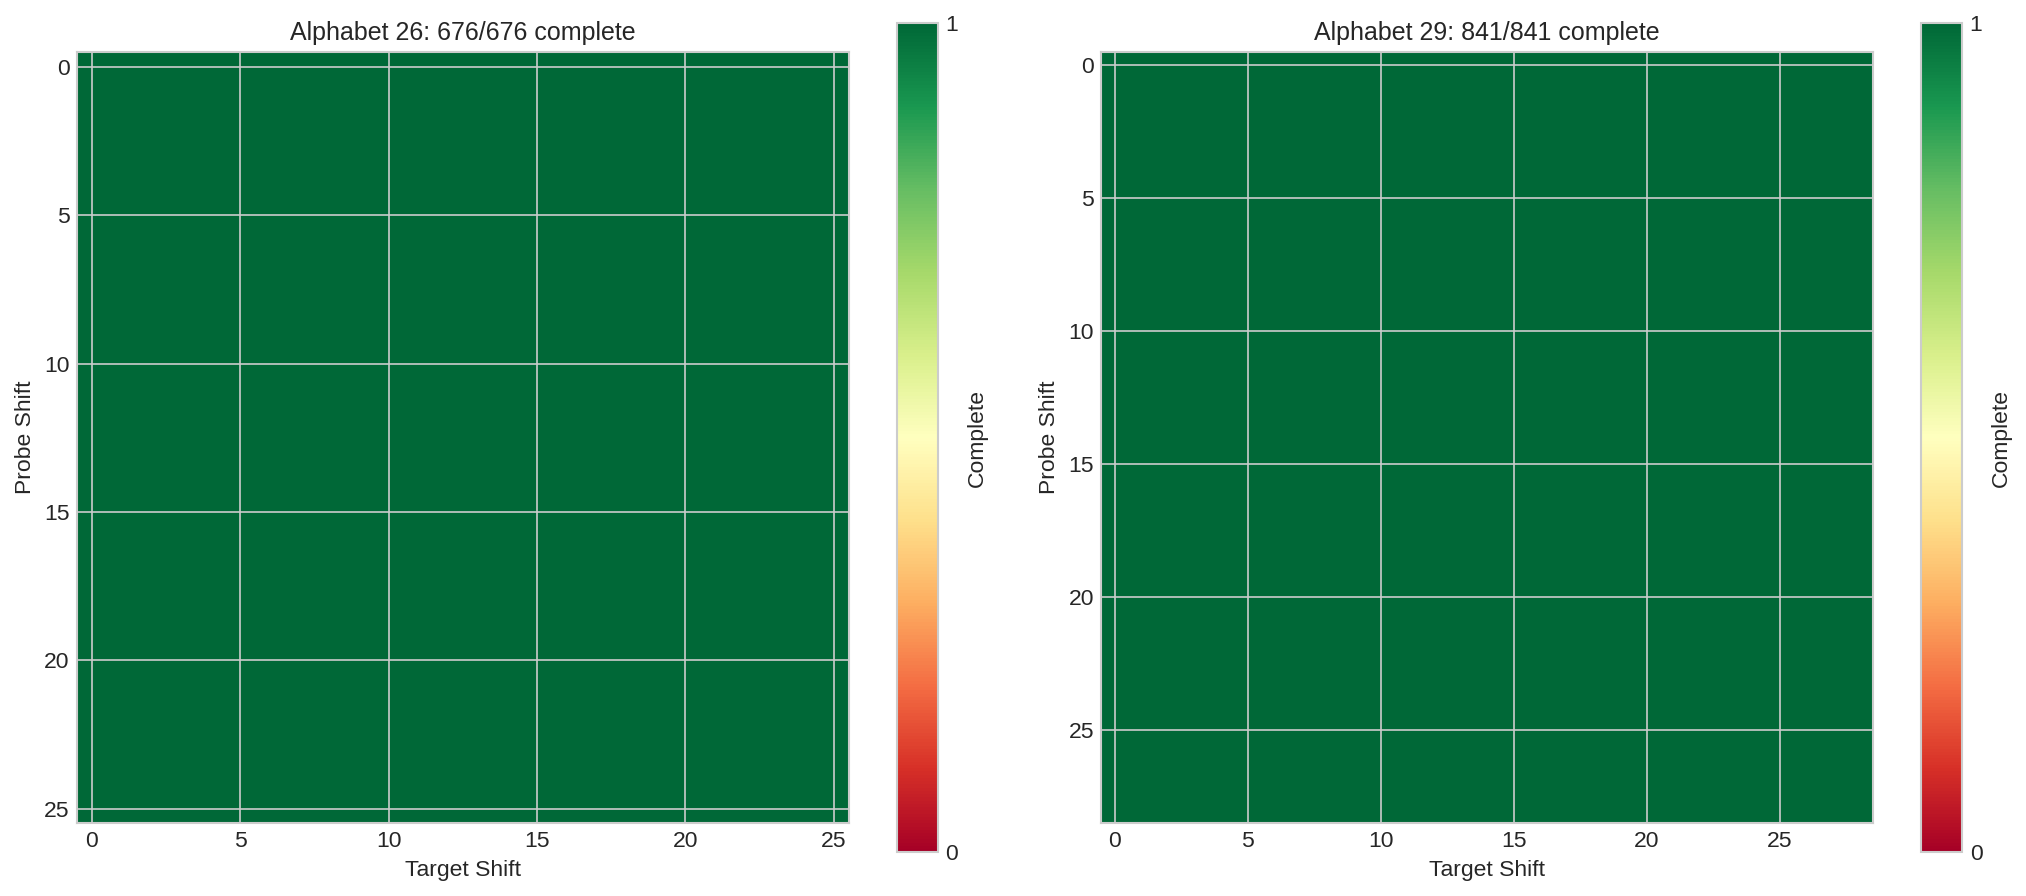

In [5]:
# Visualize completion status with heatmaps
if len(df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    for ax, alph_size in zip(axes, [26, 29]):
        # Create completion matrix
        completion = np.zeros((alph_size, alph_size))
        df_alph = df[df['alphabet_size'] == alph_size]
        
        for _, row in df_alph.iterrows():
            p, t = int(row['probe_shift']), int(row['target_shift'])
            completion[p, t] = 1
        
        # Plot
        im = ax.imshow(completion, cmap='RdYlGn', vmin=0, vmax=1, aspect='equal')
        ax.set_xlabel('Target Shift')
        ax.set_ylabel('Probe Shift')
        ax.set_title(f'Alphabet {alph_size}: {int(completion.sum())}/{alph_size**2} complete')
        
        # Add colorbar
        plt.colorbar(im, ax=ax, label='Complete', ticks=[0, 1])
    
    plt.tight_layout()
    plt.savefig('figures/completion_status.png', bbox_inches='tight')
    plt.show()
else:
    print("No data to visualize yet.")

## 3. Summary Statistics

In [6]:
if len(df) > 0 and 'targeting_score' in df.columns:
    print("="*60)
    print("TARGETING SCORE STATISTICS BY ALPHABET SIZE")
    print("="*60)
    
    for alph_size in [26, 29]:
        df_alph = df[df['alphabet_size'] == alph_size]
        if len(df_alph) > 0:
            print(f"\nAlphabet {alph_size}:")
            print(df_alph['targeting_score'].describe())
            print(f"Positive targeting: {(df_alph['targeting_score'] > 0).sum()} / {len(df_alph)} ({100*(df_alph['targeting_score'] > 0).mean():.1f}%)")
else:
    print("No targeting score data available yet.")

TARGETING SCORE STATISTICS BY ALPHABET SIZE

Alphabet 26:
count    676.000000
mean       1.339255
std        0.985008
min       -0.578502
25%        0.417490
50%        1.176528
75%        2.277824
max        3.392593
Name: targeting_score, dtype: float64
Positive targeting: 645 / 676 (95.4%)

Alphabet 29:
count    841.000000
mean       1.006093
std        0.724276
min       -0.147776
25%        0.371669
50%        0.857507
75%        1.612353
max        2.831432
Name: targeting_score, dtype: float64
Positive targeting: 813 / 841 (96.7%)


In [7]:
# Best and worst experiments
if len(df) > 0 and 'targeting_score' in df.columns:
    print("\nTop 10 Experiments by Targeting Score:")
    top_cols = ['alphabet_size', 'probe_shift', 'target_shift', 'targeting_score', 
                'delta_ce_target', 'delta_ce_other']
    display_cols = [c for c in top_cols if c in df.columns]
    print(df.nlargest(10, 'targeting_score')[display_cols].to_string())
    
    print("\n\nBottom 10 Experiments by Targeting Score:")
    print(df.nsmallest(10, 'targeting_score')[display_cols].to_string())


Top 10 Experiments by Targeting Score:
     alphabet_size  probe_shift  target_shift  targeting_score  delta_ce_target  delta_ce_other
182             26           16             0         3.392593        -4.277564       -0.884971
202             26           16             4         3.297784        -4.167607       -0.869823
194             26           16             2         3.284342        -4.097347       -0.813004
666             26            9            23         3.205971        -4.263553       -1.057583
263             26           19            11         3.183133        -4.536731       -1.353598
125             26           13             5         3.182940        -3.970797       -0.787857
334             26           20             6         3.176448        -4.309808       -1.133360
669             26            9             3         3.101369        -3.356447       -0.255077
384             26           22             4         3.093746        -3.807930       -0.714184


## 4. Targeting Score Distribution Comparison

Compare targeting score distributions between alphabet sizes.

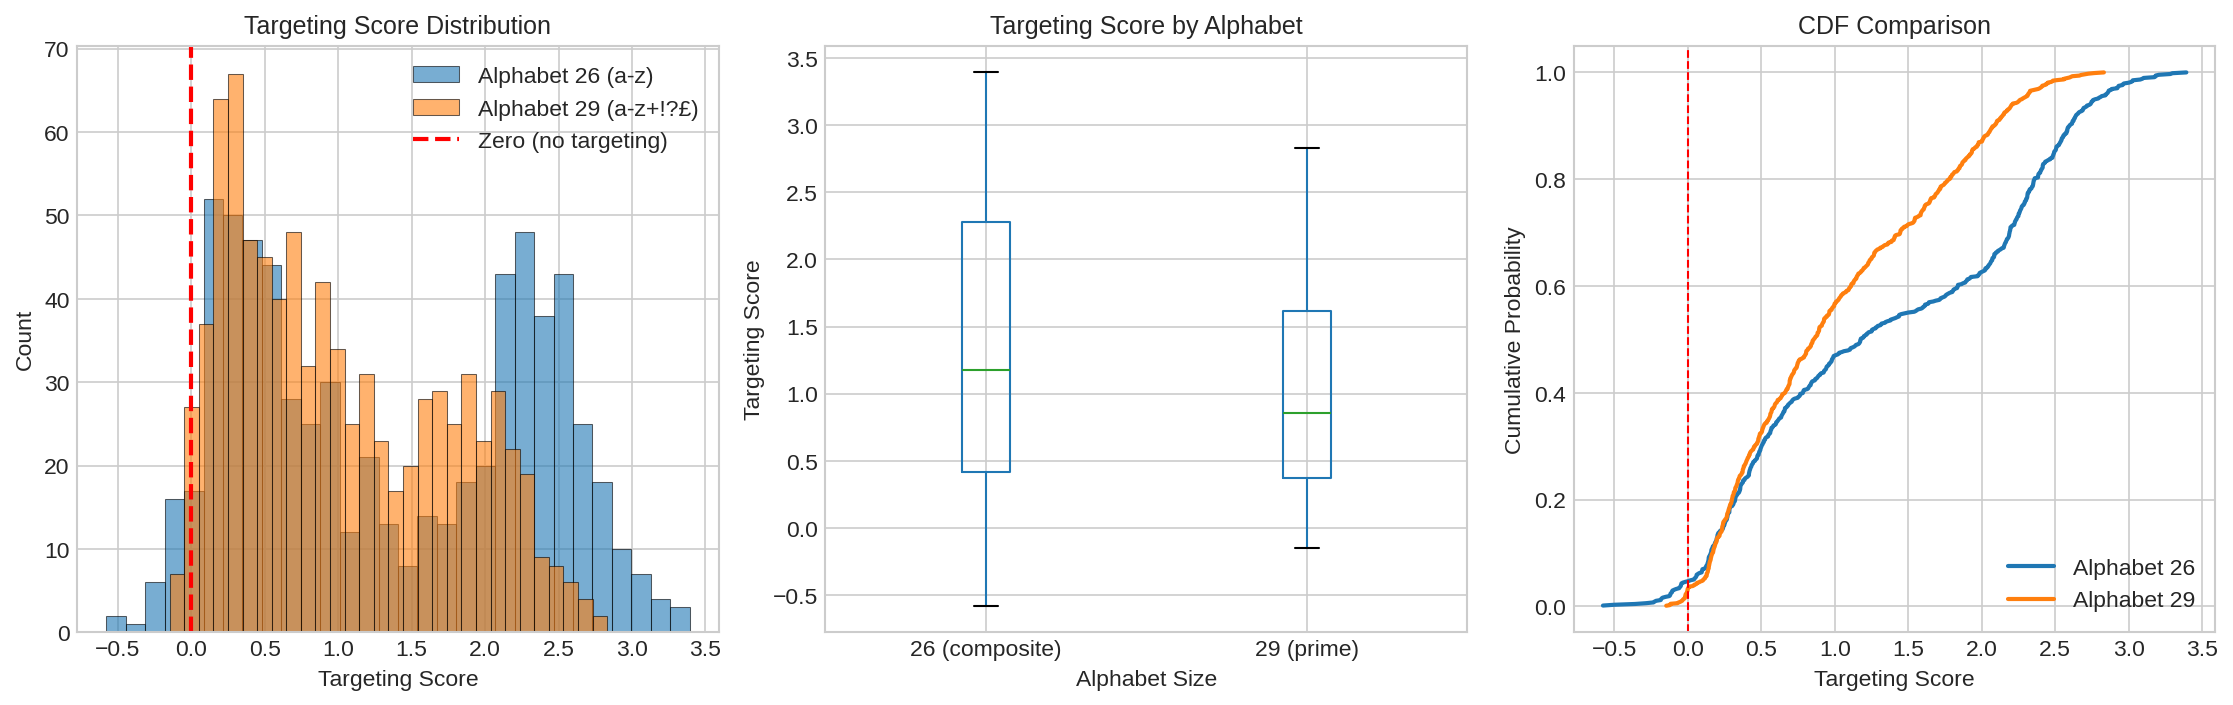

In [8]:
if len(df) > 0 and 'targeting_score' in df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Separate histograms
    ax = axes[0]
    for alph_size, color, label in [(26, 'C0', 'Alphabet 26 (a-z)'), 
                                     (29, 'C1', 'Alphabet 29 (a-z+!?£)')]:
        df_alph = df[df['alphabet_size'] == alph_size]
        if len(df_alph) > 0:
            ax.hist(df_alph['targeting_score'], bins=30, alpha=0.6, 
                    label=label, color=color, edgecolor='black', linewidth=0.5)
    
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero (no targeting)')
    ax.set_xlabel('Targeting Score')
    ax.set_ylabel('Count')
    ax.set_title('Targeting Score Distribution')
    ax.legend()
    
    # Box plot comparison
    ax = axes[1]
    df_plot = df[df['alphabet_size'].isin([26, 29])].copy()
    df_plot['alphabet_label'] = df_plot['alphabet_size'].map({26: '26 (composite)', 29: '29 (prime)'})
    df_plot.boxplot(column='targeting_score', by='alphabet_label', ax=ax)
    ax.set_xlabel('Alphabet Size')
    ax.set_ylabel('Targeting Score')
    ax.set_title('Targeting Score by Alphabet')
    plt.suptitle('')  # Remove automatic title
    
    # CDF comparison
    ax = axes[2]
    for alph_size, color, label in [(26, 'C0', 'Alphabet 26'), (29, 'C1', 'Alphabet 29')]:
        df_alph = df[df['alphabet_size'] == alph_size]
        if len(df_alph) > 0:
            sorted_scores = np.sort(df_alph['targeting_score'])
            cdf = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
            ax.plot(sorted_scores, cdf, label=label, color=color, linewidth=2)
    
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Targeting Score')
    ax.set_ylabel('Cumulative Probability')
    ax.set_title('CDF Comparison')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('figures/targeting_score_comparison.png', bbox_inches='tight')
    plt.show()
else:
    print("Insufficient data for plotting.")

## 5. Targeting Score Heatmaps

Visualize targeting success across all (probe_shift, target_shift) combinations.

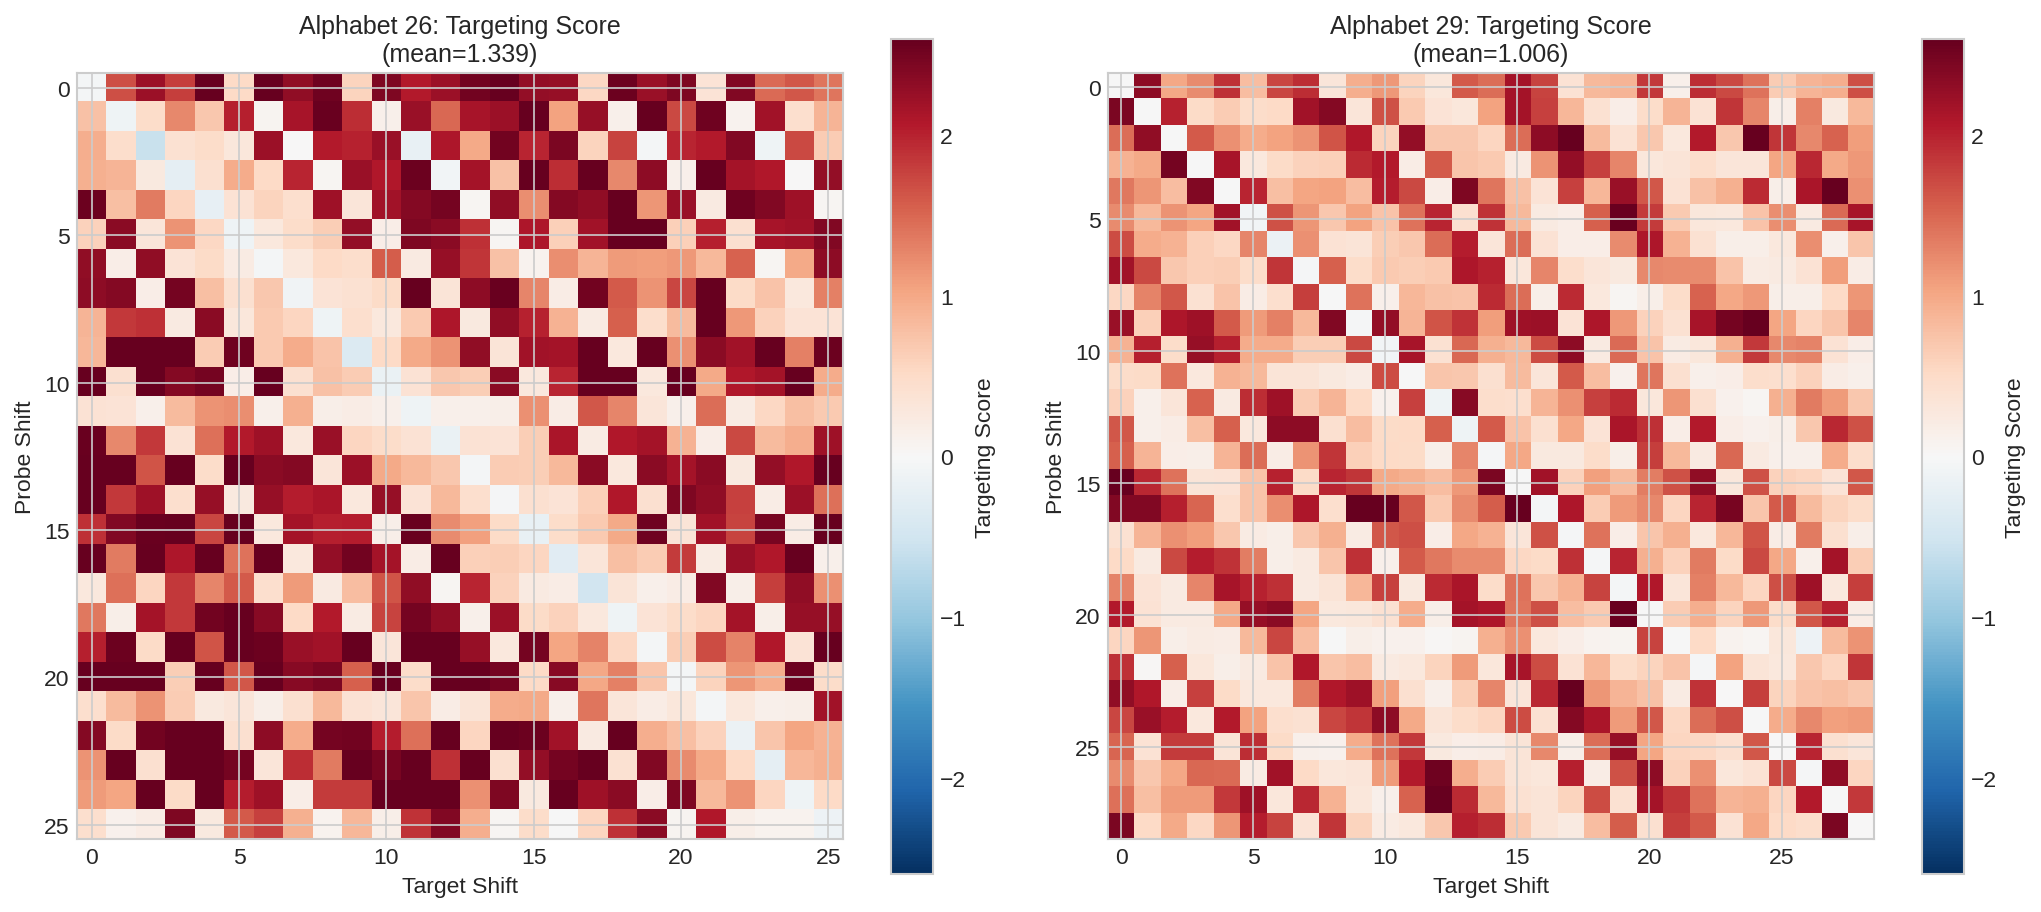

In [9]:
if len(df) > 0 and 'targeting_score' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Get common color scale
    vmin = df['targeting_score'].quantile(0.05)
    vmax = df['targeting_score'].quantile(0.95)
    vabs = max(abs(vmin), abs(vmax))
    
    for ax, alph_size in zip(axes, [26, 29]):
        df_alph = df[df['alphabet_size'] == alph_size]
        
        if len(df_alph) > 0:
            # Create heatmap matrix
            heatmap = np.full((alph_size, alph_size), np.nan)
            for _, row in df_alph.iterrows():
                p, t = int(row['probe_shift']), int(row['target_shift'])
                heatmap[p, t] = row['targeting_score']
            
            # Plot
            im = ax.imshow(heatmap, cmap='RdBu_r', vmin=-vabs, vmax=vabs, aspect='equal')
            ax.set_xlabel('Target Shift')
            ax.set_ylabel('Probe Shift')
            ax.set_title(f'Alphabet {alph_size}: Targeting Score\n(mean={df_alph["targeting_score"].mean():.3f})')
            plt.colorbar(im, ax=ax, label='Targeting Score')
        else:
            ax.set_title(f'Alphabet {alph_size}: No data')
    
    plt.tight_layout()
    plt.savefig('figures/targeting_heatmaps.png', bbox_inches='tight')
    plt.show()
else:
    print("Insufficient data for heatmaps.")

## 6. Shift Difference Analysis

Analyze how targeting success varies with the distance between probe and target shifts.

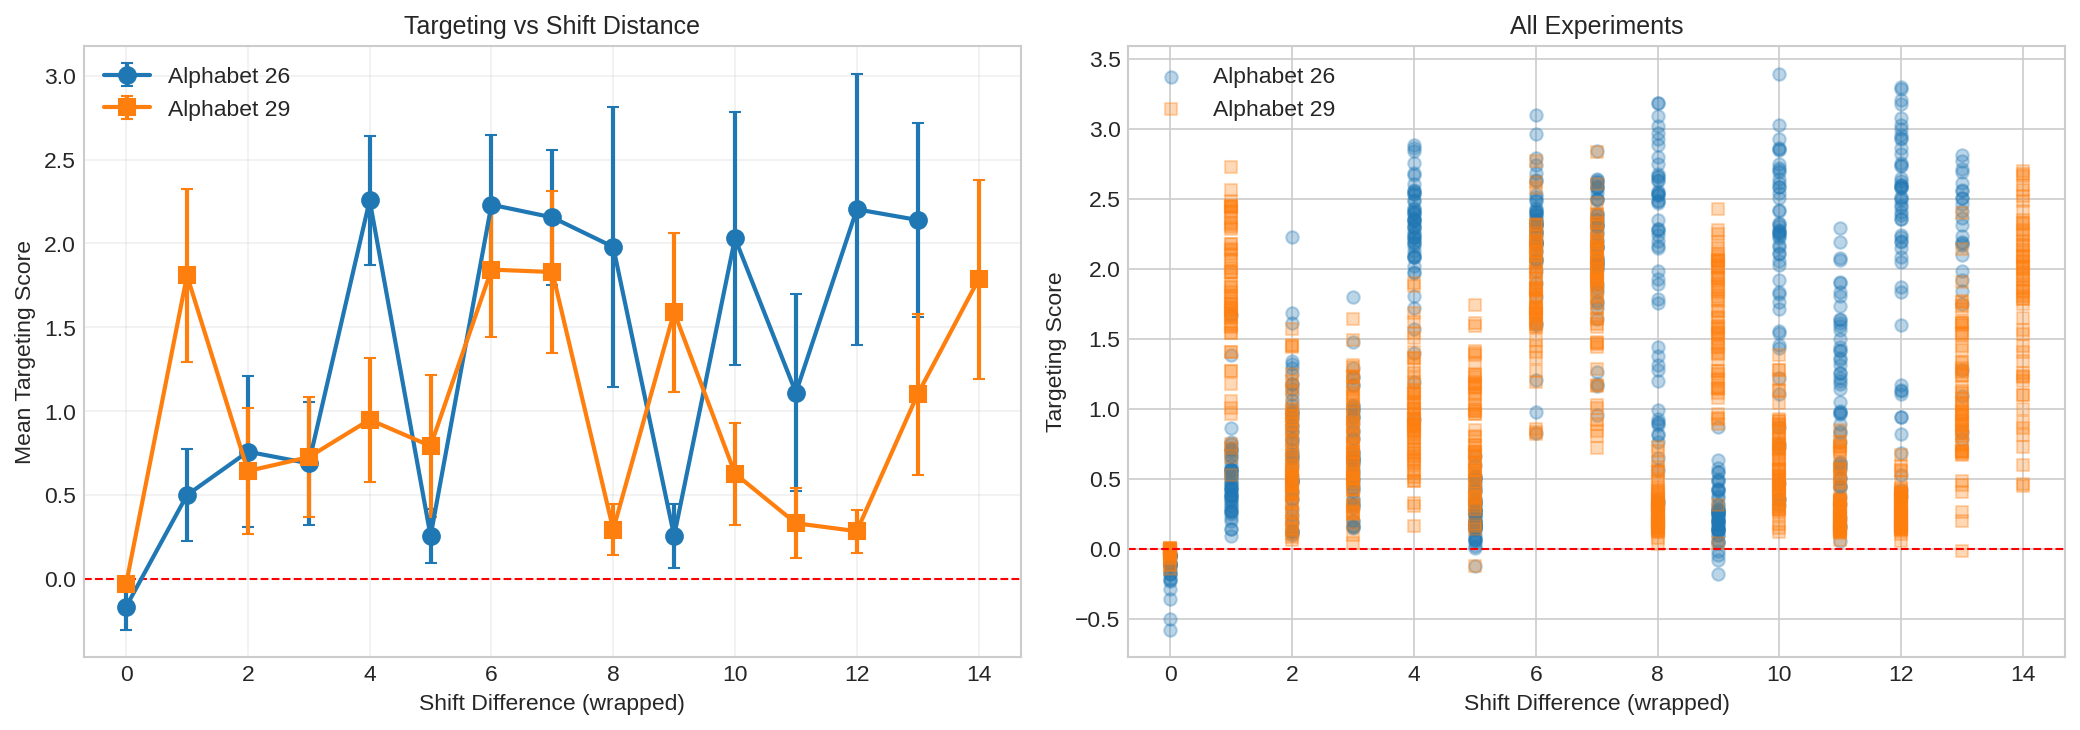

In [10]:
if len(df) > 0 and 'targeting_score' in df.columns:
    # Compute shift difference (wrapped to half-alphabet)
    df['shift_diff_raw'] = (df['target_shift'] - df['probe_shift']).abs()
    df['shift_diff_wrapped'] = df.apply(
        lambda row: min(row['shift_diff_raw'], row['alphabet_size'] - row['shift_diff_raw']), 
        axis=1
    )
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Targeting vs shift difference
    ax = axes[0]
    for alph_size, color, marker in [(26, 'C0', 'o'), (29, 'C1', 's')]:
        df_alph = df[df['alphabet_size'] == alph_size]
        if len(df_alph) > 0:
            means = df_alph.groupby('shift_diff_wrapped')['targeting_score'].mean()
            stds = df_alph.groupby('shift_diff_wrapped')['targeting_score'].std()
            ax.errorbar(means.index, means.values, yerr=stds.values, 
                       marker=marker, color=color, label=f'Alphabet {alph_size}',
                       capsize=3, linewidth=2, markersize=8)
    
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Shift Difference (wrapped)')
    ax.set_ylabel('Mean Targeting Score')
    ax.set_title('Targeting vs Shift Distance')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Scatter plot
    ax = axes[1]
    for alph_size, color, marker in [(26, 'C0', 'o'), (29, 'C1', 's')]:
        df_alph = df[df['alphabet_size'] == alph_size]
        if len(df_alph) > 0:
            ax.scatter(df_alph['shift_diff_wrapped'], df_alph['targeting_score'],
                      alpha=0.3, color=color, marker=marker, label=f'Alphabet {alph_size}')
    
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Shift Difference (wrapped)')
    ax.set_ylabel('Targeting Score')
    ax.set_title('All Experiments')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('figures/shift_difference_analysis.png', bbox_inches='tight')
    plt.show()

## 7. Fourier/GCD Analysis

Test whether shifts sharing factors with the alphabet size are harder to attack.

- **Alphabet 26** = 2 × 13 (composite): shifts with GCD > 1 may be problematic
- **Alphabet 29** (prime): all shifts coprime, no special structure

In [11]:
def factorize(n):
    """Return prime factors of n."""
    factors = []
    d = 2
    while d * d <= n:
        while n % d == 0:
            factors.append(d)
            n //= d
        d += 1
    if n > 1:
        factors.append(n)
    return factors if factors else [n]

if len(df) > 0 and 'targeting_score' in df.columns:
    # Compute GCD with alphabet size
    df['gcd_with_alph'] = df.apply(
        lambda row: math.gcd(int(row['shift_diff_wrapped']), int(row['alphabet_size'])),
        axis=1
    )
    df['is_coprime'] = df['gcd_with_alph'] == 1
    
    print("="*60)
    print("GCD ANALYSIS")
    print("="*60)
    
    for alph_size in [26, 29]:
        df_alph = df[df['alphabet_size'] == alph_size]
        if len(df_alph) > 0:
            print(f"\nAlphabet {alph_size}:")
            print(f"  Factors: {alph_size} = {' × '.join(str(f) for f in factorize(alph_size))}")
            print(f"  GCD distribution:")
            for gcd_val in sorted(df_alph['gcd_with_alph'].unique()):
                df_gcd = df_alph[df_alph['gcd_with_alph'] == gcd_val]
                print(f"    GCD={gcd_val}: n={len(df_gcd)}, mean_targeting={df_gcd['targeting_score'].mean():.4f}")

GCD ANALYSIS

Alphabet 26:
  Factors: 26 = 2 × 13
  GCD distribution:
    GCD=1: n=312, mean_targeting=0.8273
    GCD=2: n=312, mean_targeting=1.9100
    GCD=13: n=26, mean_targeting=2.1398
    GCD=26: n=26, mean_targeting=-0.1665

Alphabet 29:
  Factors: 29 = 29
  GCD distribution:
    GCD=1: n=812, mean_targeting=1.0431
    GCD=29: n=29, mean_targeting=-0.0309


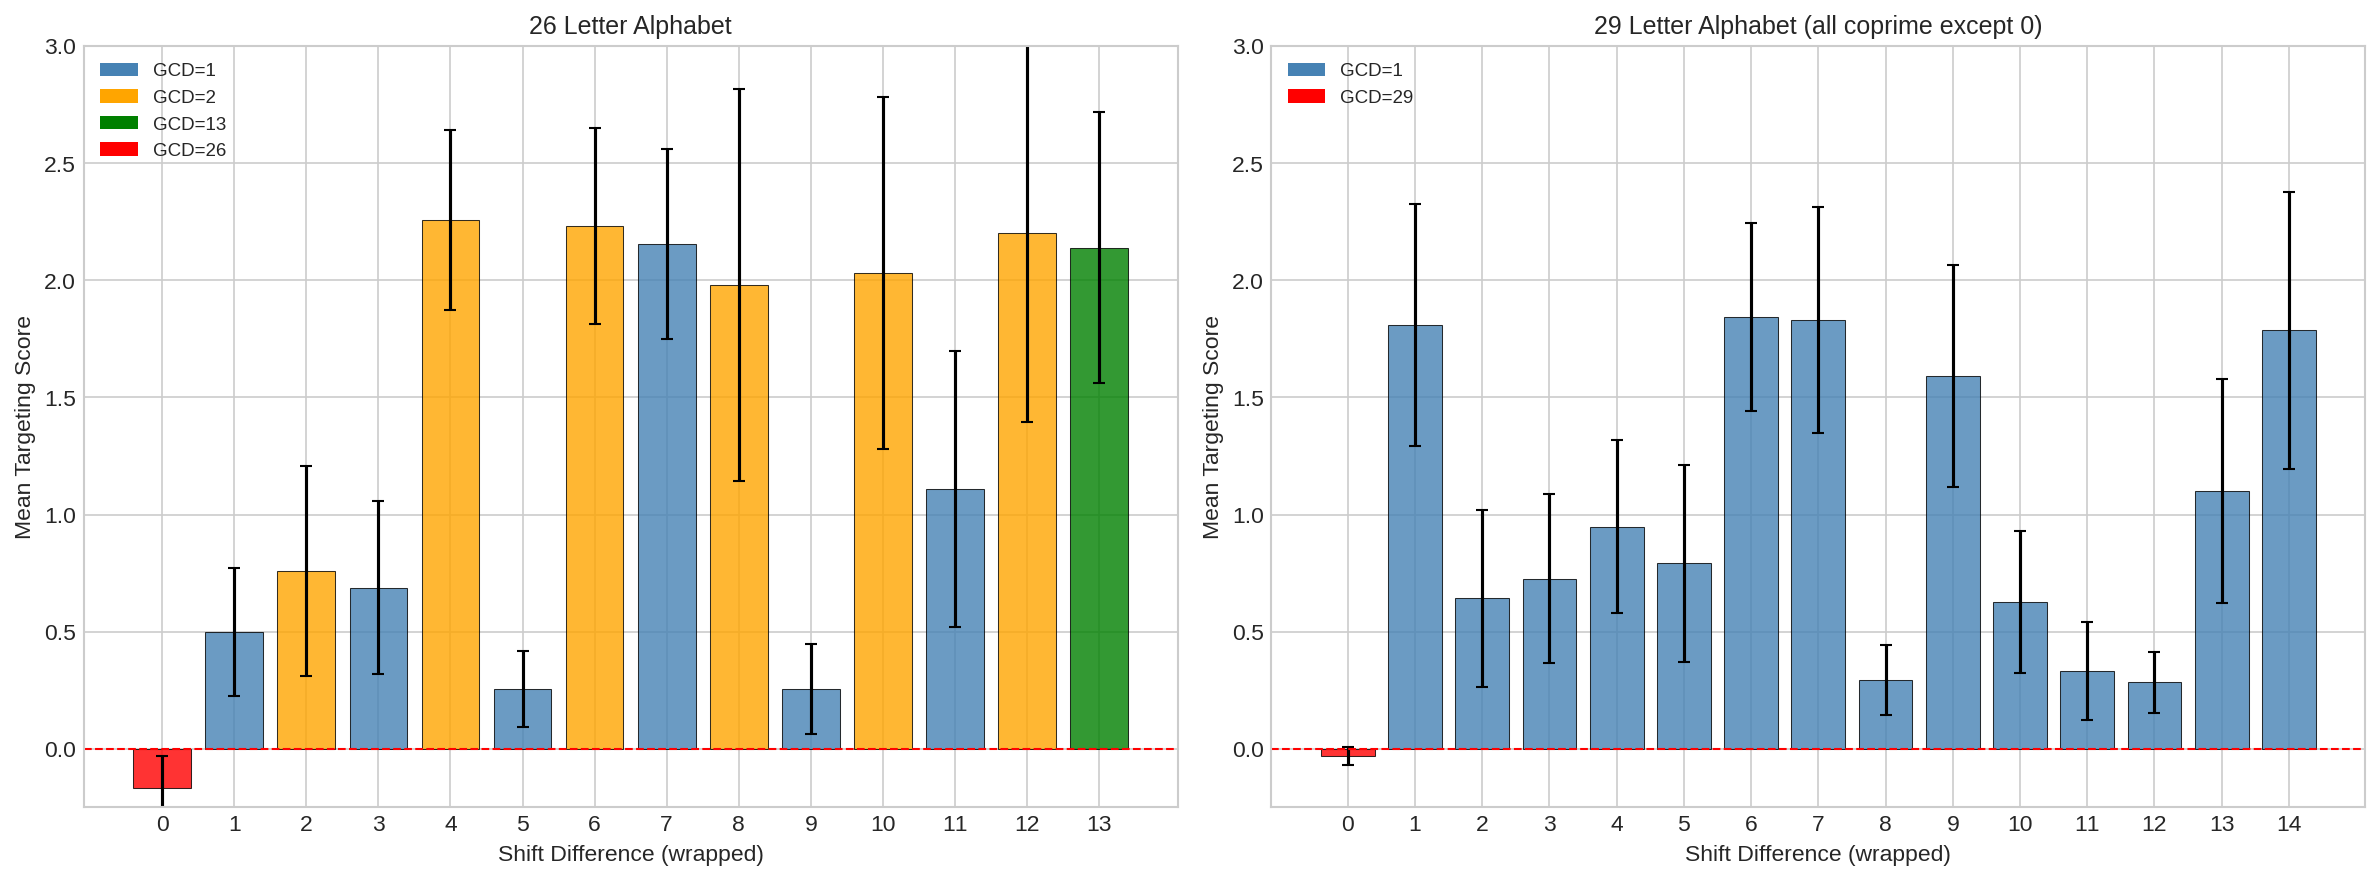


DETAILED RESULTS: TARGETING SCORE BY SHIFT DIFFERENCE

--------------------------------------------------------------------------------
ALPHABET 26 (a-z) - 26 = 2 × 13
--------------------------------------------------------------------------------
 Shift   GCD     Mean      Std      N
----------------------------------------
     0    26   -0.167    0.137     26
     1     1    0.499    0.273     52
     2     2    0.758    0.449     52
     3     1    0.688    0.368     52
     4     2    2.257    0.384     52
     5     1    0.255    0.162     52
     6     2    2.231    0.417     52
     7     1    2.155    0.404     52
     8     2    1.979    0.836     52
     9     1    0.256    0.192     52
    10     2    2.031    0.753     52
    11     1    1.110    0.588     52
    12     2    2.204    0.808     52
    13    13    2.140    0.577     26

--------------------------------------------------------------------------------
ALPHABET 29 (a-z + !?£) - 29 is PRIME
-------------------

In [ ]:
if len(df) > 0 and 'targeting_score' in df.columns and 'gcd_with_alph' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # Wider for x-axis

    # Color maps for GCD values
    gcd_colors_26 = {1: 'steelblue', 2: 'orange', 13: 'green', 26: 'red'}
    gcd_colors_29 = {1: 'steelblue', 29: 'red'}  # 29 is prime, only GCD=1 or 29

    # ===== Vertical Bar plots by shift difference with GCD coloring =====

    # Alphabet 26
    ax = axes[0]
    df_26 = df[df['alphabet_size'] == 26]
    if len(df_26) > 0:
        shift_means_26 = df_26.groupby('shift_diff_wrapped')['targeting_score'].mean()
        shift_stds_26 = df_26.groupby('shift_diff_wrapped')['targeting_score'].std()
        shift_counts_26 = df_26.groupby('shift_diff_wrapped').size()

        # Get GCD for each shift difference
        shifts = shift_means_26.index.values
        colors = [gcd_colors_26.get(math.gcd(int(s), 26), 'gray') for s in shifts]

        # Vertical bar plot
        import numpy as np
        x_pos = np.arange(len(shifts))
        bars = ax.bar(x_pos, shift_means_26.values, yerr=shift_stds_26.values,
                      capsize=3, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
        ax.axhline(0, color='red', linestyle='--', linewidth=1)
        ax.set_xlabel('Shift Difference (wrapped)')
        ax.set_ylabel('Mean Targeting Score')
        ax.set_title('26 Letter Alphabet')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(shifts)
        ax.set_ylim(bottom=-0.25, top=3)  # Make y axis go up to 3

        # Legend moved to upper left
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=c, label=f'GCD={g}') 
                          for g, c in sorted(gcd_colors_26.items())]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

    # Alphabet 29
    ax = axes[1]
    df_29 = df[df['alphabet_size'] == 29]
    if len(df_29) > 0:
        shift_means_29 = df_29.groupby('shift_diff_wrapped')['targeting_score'].mean()
        shift_stds_29 = df_29.groupby('shift_diff_wrapped')['targeting_score'].std()
        shift_counts_29 = df_29.groupby('shift_diff_wrapped').size()

        shifts = shift_means_29.index.values
        colors = [gcd_colors_29.get(math.gcd(int(s), 29), 'steelblue') for s in shifts]

        x_pos = np.arange(len(shifts))
        bars = ax.bar(x_pos, shift_means_29.values, yerr=shift_stds_29.values,
                      capsize=3, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
        ax.axhline(0, color='red', linestyle='--', linewidth=1)
        ax.set_xlabel('Shift Difference (wrapped)')
        ax.set_ylabel('Mean Targeting Score')
        ax.set_title('29 Letter Alphabet')
        ax.set_xticks(x_pos)
        ax.set_xticklabels(shifts)
        ax.set_ylim(bottom=-0.25, top=3)  # Make y axis go up to 3

        legend_elements = [Patch(facecolor=c, label=f'GCD={g}') 
                          for g, c in sorted(gcd_colors_29.items())]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

    plt.tight_layout()
    plt.savefig('figures/gcd_analysis.png', bbox_inches='tight', dpi=150)
    plt.show()

    # ===== DETAILED TEXT OUTPUT =====
    print("\n" + "="*80)
    print("DETAILED RESULTS: TARGETING SCORE BY SHIFT DIFFERENCE")
    print("="*80)

    # Alphabet 26 table
    if len(df_26) > 0:
        print("\n" + "-"*80)
        print("ALPHABET 26 (a-z) - 26 = 2 × 13")
        print("-"*80)
        print(f"{'Shift':>6} {'GCD':>5} {'Mean':>8} {'Std':>8} {'N':>6}")
        print("-"*40)
        for shift in sorted(shift_means_26.index):
            gcd = math.gcd(int(shift), 26)
            mean = shift_means_26[shift]
            std = shift_stds_26[shift]
            n = shift_counts_26[shift]
            print(f"{int(shift):>6} {gcd:>5} {mean:>8.3f} {std:>8.3f} {n:>6}")

    # Alphabet 29 table
    if len(df_29) > 0:
        print("\n" + "-"*80)
        print("ALPHABET 29 (a-z + !?£) - 29 is PRIME")
        print("-"*80)
        print(f"{'Shift':>6} {'GCD':>5} {'Mean':>8} {'Std':>8} {'N':>6}")
        print("-"*40)
        for shift in sorted(shift_means_29.index):
            gcd = math.gcd(int(shift), 29)
            mean = shift_means_29[shift]
            std = shift_stds_29[shift]
            n = shift_counts_29[shift]
            print(f"{int(shift):>6} {gcd:>5} {mean:>8.3f} {std:>8.3f} {n:>6}")

    # GCD Summary
    print("\n" + "="*80)
    print("GCD ANALYSIS SUMMARY")
    print("="*80)
    if len(df_26) > 0:
        print("\n26Alphabet 26 (26 = 2 × 13):")
        for gcd in sorted(df_26['gcd_with_alph'].unique()):
            subset = df_26[df_26['gcd_with_alph'] == gcd]
            print(f"  GCD={gcd:2d}: mean={subset['targeting_score'].mean():.3f} ± {subset['targeting_score'].std():.3f} (n={len(subset)})")
    if len(df_29) > 0:
        print("\nAlphabet 29 (prime):")
        for gcd in sorted(df_29['gcd_with_alph'].unique()):
            subset = df_29[df_29['gcd_with_alph'] == gcd]
            print(f"  GCD={gcd:2d}: mean={subset['targeting_score'].mean():.3f} ± {subset['targeting_score'].std():.3f} (n={len(subset)})")

## 8. Statistical Tests

In [13]:
if len(df) > 0 and 'targeting_score' in df.columns:
    print("="*60)
    print("STATISTICAL TESTS")
    print("="*60)
    
    df_26 = df[df['alphabet_size'] == 26]['targeting_score'].dropna()
    df_29 = df[df['alphabet_size'] == 29]['targeting_score'].dropna()
    
    if len(df_26) > 0 and len(df_29) > 0:
        # Two-sample t-test
        t_stat, p_value = stats.ttest_ind(df_26, df_29)
        print(f"\n1. Two-sample t-test (26 vs 29):")
        print(f"   t-statistic: {t_stat:.4f}")
        print(f"   p-value: {p_value:.4e}")
        print(f"   Significant at α=0.05: {p_value < 0.05}")
        
        # Mann-Whitney U test (non-parametric)
        u_stat, p_value_mw = stats.mannwhitneyu(df_26, df_29, alternative='two-sided')
        print(f"\n2. Mann-Whitney U test:")
        print(f"   U-statistic: {u_stat:.4f}")
        print(f"   p-value: {p_value_mw:.4e}")
        print(f"   Significant at α=0.05: {p_value_mw < 0.05}")
        
        # Effect size (Cohen's d)
        pooled_std = np.sqrt((df_26.std()**2 + df_29.std()**2) / 2)
        cohens_d = (df_26.mean() - df_29.mean()) / pooled_std
        print(f"\n3. Effect size (Cohen's d): {cohens_d:.4f}")
        print(f"   Interpretation: {'small' if abs(cohens_d) < 0.5 else 'medium' if abs(cohens_d) < 0.8 else 'large'}")
    
    # Within alphabet 26: coprime vs non-coprime
    df_26_full = df[df['alphabet_size'] == 26]
    if len(df_26_full) > 0 and 'is_coprime' in df_26_full.columns:
        coprime = df_26_full[df_26_full['is_coprime']]['targeting_score'].dropna()
        non_coprime = df_26_full[~df_26_full['is_coprime']]['targeting_score'].dropna()
        
        if len(coprime) > 0 and len(non_coprime) > 0:
            t_stat, p_value = stats.ttest_ind(coprime, non_coprime)
            print(f"\n4. Within Alphabet 26: Coprime vs Non-coprime shifts")
            print(f"   Coprime mean: {coprime.mean():.4f} (n={len(coprime)})")
            print(f"   Non-coprime mean: {non_coprime.mean():.4f} (n={len(non_coprime)})")
            print(f"   t-statistic: {t_stat:.4f}")
            print(f"   p-value: {p_value:.4e}")
else:
    print("Insufficient data for statistical tests.")

STATISTICAL TESTS

1. Two-sample t-test (26 vs 29):
   t-statistic: 7.5844
   p-value: 5.7940e-14
   Significant at α=0.05: True

2. Mann-Whitney U test:
   U-statistic: 337603.0000
   p-value: 3.1680e-10
   Significant at α=0.05: True

3. Effect size (Cohen's d): 0.3854
   Interpretation: small

4. Within Alphabet 26: Coprime vs Non-coprime shifts
   Coprime mean: 0.8273 (n=312)
   Non-coprime mean: 1.7781 (n=364)
   t-statistic: -14.2655
   p-value: 1.5349e-40


## 9. CE Change Analysis

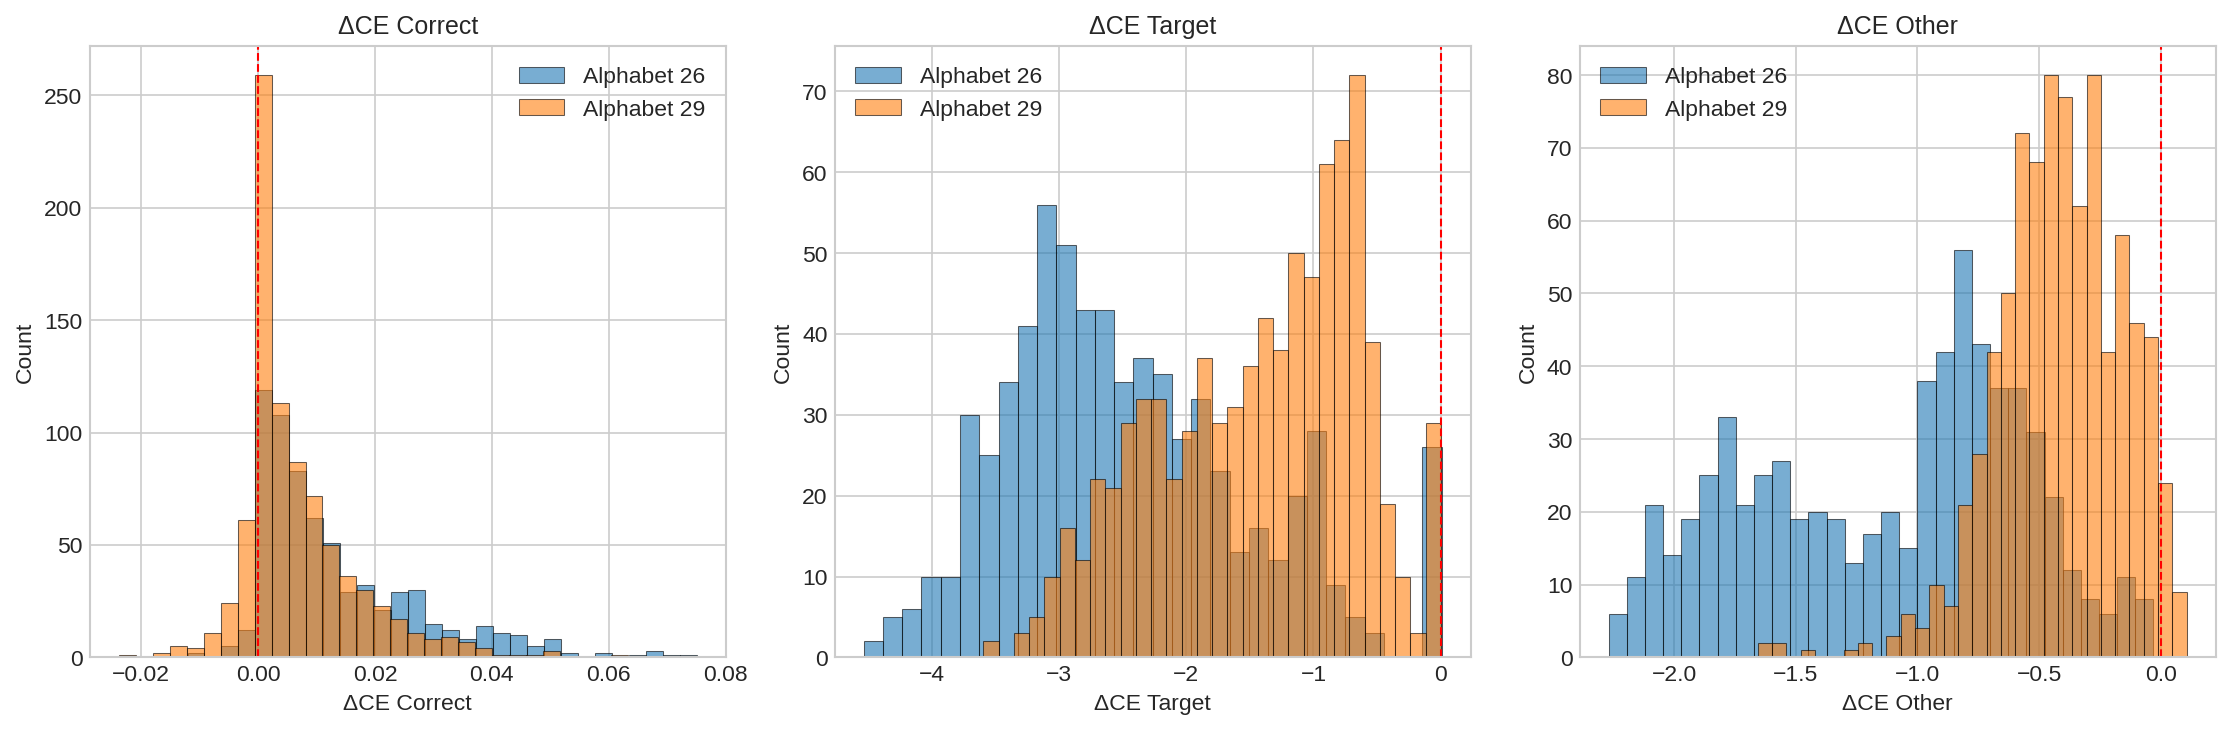

In [14]:
if len(df) > 0 and all(c in df.columns for c in ['delta_ce_correct', 'delta_ce_target', 'delta_ce_other']):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    metrics = ['delta_ce_correct', 'delta_ce_target', 'delta_ce_other']
    titles = ['ΔCE Correct', 'ΔCE Target', 'ΔCE Other']
    
    for ax, metric, title in zip(axes, metrics, titles):
        for alph_size, color in [(26, 'C0'), (29, 'C1')]:
            df_alph = df[df['alphabet_size'] == alph_size]
            if len(df_alph) > 0:
                ax.hist(df_alph[metric], bins=30, alpha=0.6, 
                       label=f'Alphabet {alph_size}', color=color, edgecolor='black', linewidth=0.5)
        
        ax.axvline(0, color='red', linestyle='--', linewidth=1)
        ax.set_xlabel(title)
        ax.set_ylabel('Count')
        ax.set_title(title)
        ax.legend()
    
    plt.tight_layout()
    plt.savefig('figures/ce_changes.png', bbox_inches='tight')
    plt.show()

## 10. Paper-Ready Summary Figure

/local/user/1483801484/ipykernel_279077/564932855.py:84: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax6.boxplot(data_to_plot, labels=labels, patch_artist=True)


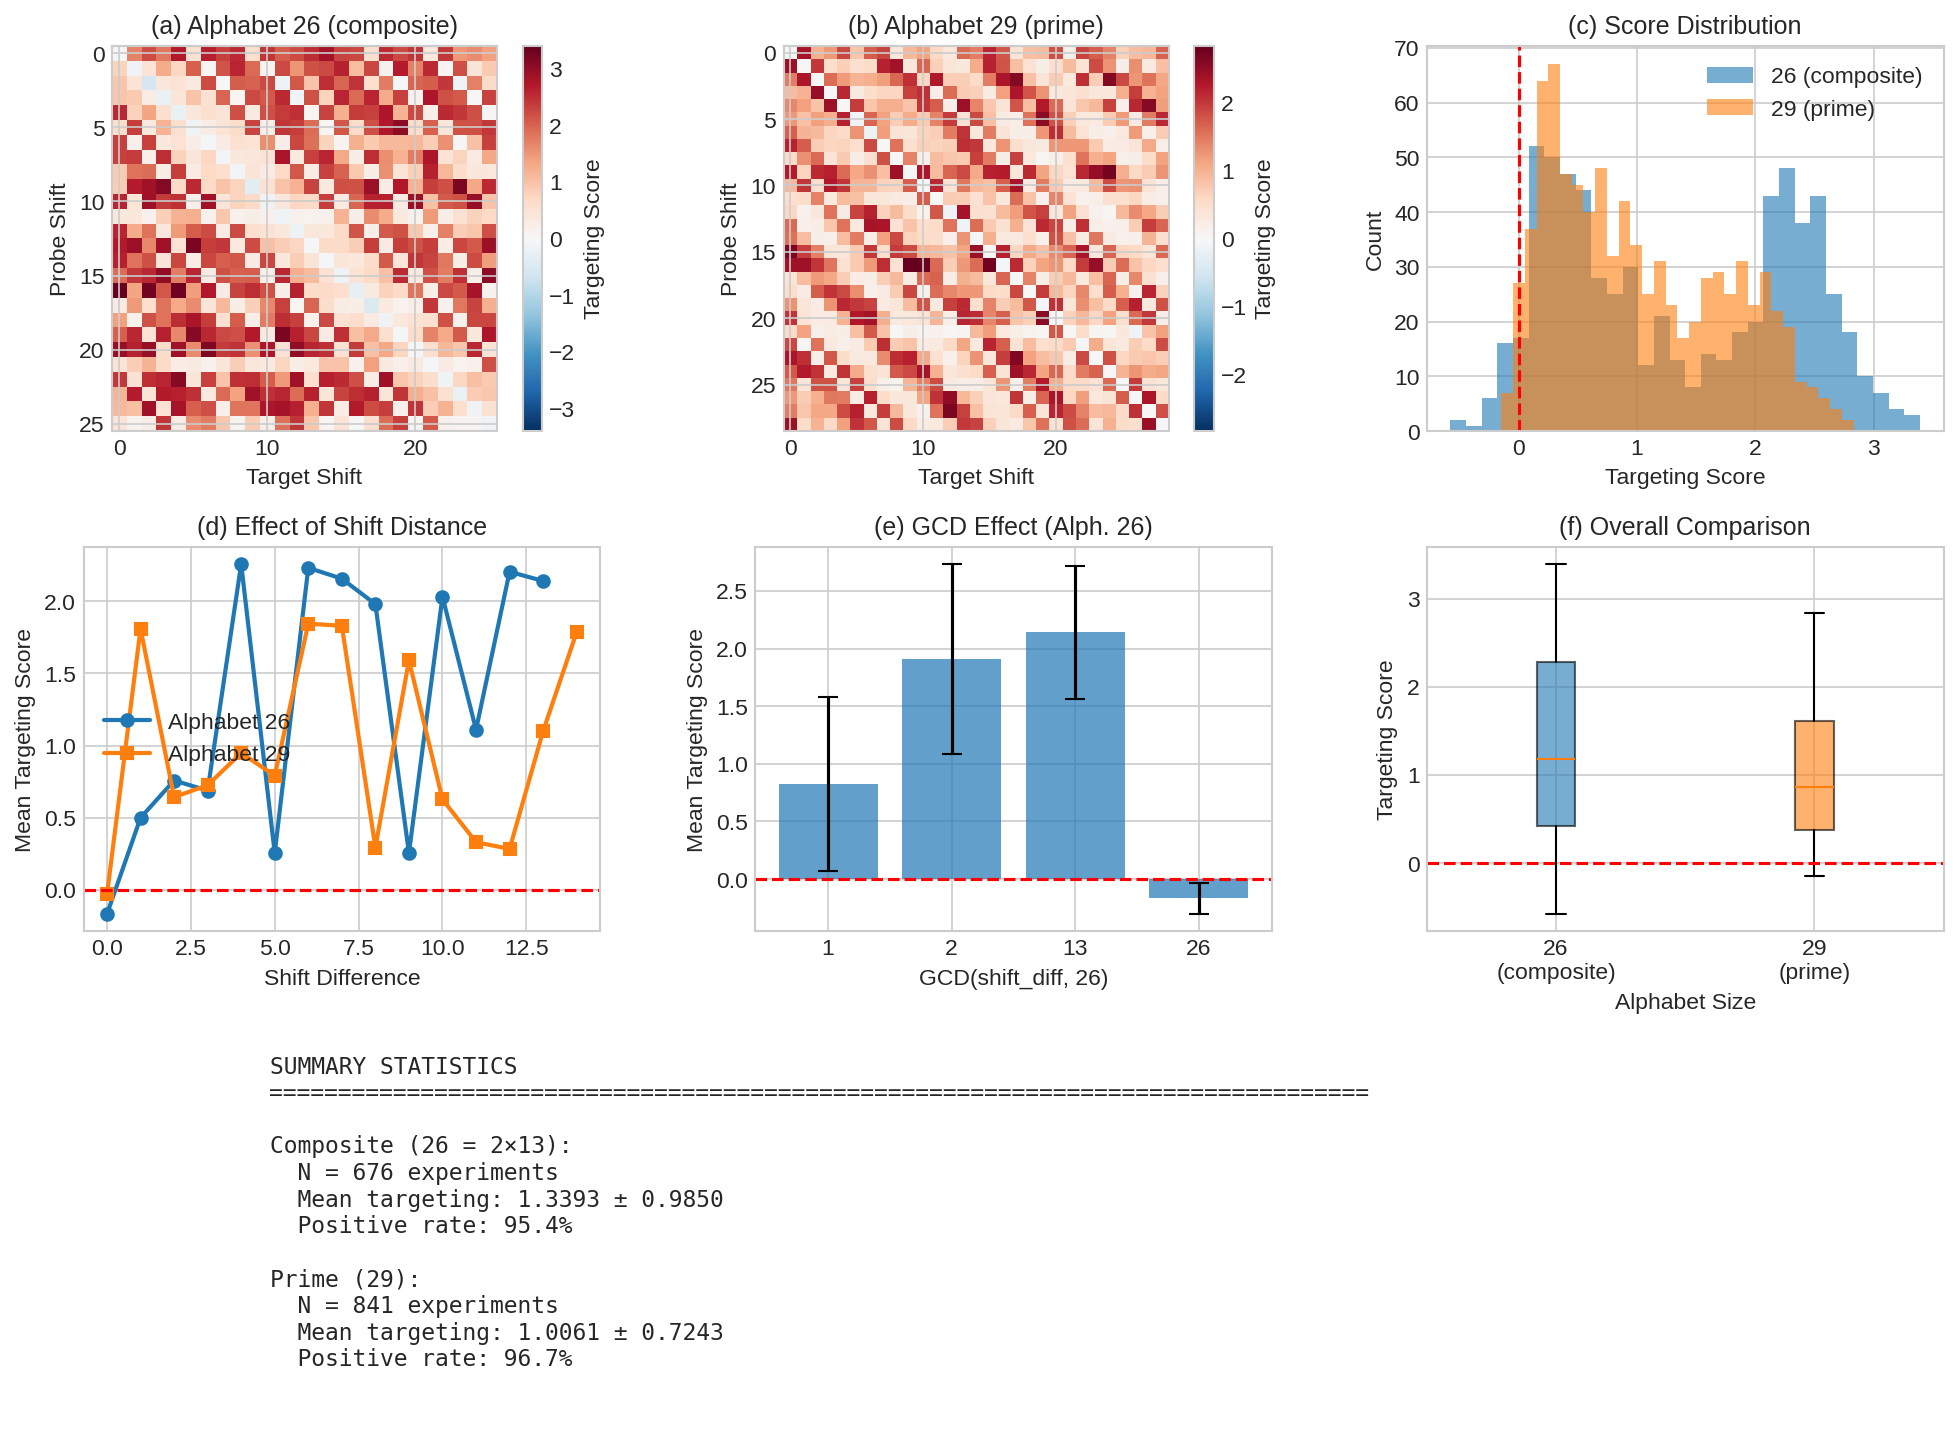


Figure saved to figures/paper_summary.png and figures/paper_summary.pdf


In [15]:
if len(df) > 0 and 'targeting_score' in df.columns:
    fig = plt.figure(figsize=(16, 12))
    
    # Create grid
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # (a) Targeting heatmap - Alphabet 26
    ax1 = fig.add_subplot(gs[0, 0])
    df_26 = df[df['alphabet_size'] == 26]
    if len(df_26) > 0:
        heatmap = np.full((26, 26), np.nan)
        for _, row in df_26.iterrows():
            heatmap[int(row['probe_shift']), int(row['target_shift'])] = row['targeting_score']
        vabs = max(abs(np.nanmin(heatmap)), abs(np.nanmax(heatmap)))
        im = ax1.imshow(heatmap, cmap='RdBu_r', vmin=-vabs, vmax=vabs)
        ax1.set_xlabel('Target Shift')
        ax1.set_ylabel('Probe Shift')
        ax1.set_title('(a) Alphabet 26 (composite)')
        plt.colorbar(im, ax=ax1, label='Targeting Score')
    
    # (b) Targeting heatmap - Alphabet 29
    ax2 = fig.add_subplot(gs[0, 1])
    df_29 = df[df['alphabet_size'] == 29]
    if len(df_29) > 0:
        heatmap = np.full((29, 29), np.nan)
        for _, row in df_29.iterrows():
            heatmap[int(row['probe_shift']), int(row['target_shift'])] = row['targeting_score']
        vabs = max(abs(np.nanmin(heatmap)), abs(np.nanmax(heatmap)))
        im = ax2.imshow(heatmap, cmap='RdBu_r', vmin=-vabs, vmax=vabs)
        ax2.set_xlabel('Target Shift')
        ax2.set_ylabel('Probe Shift')
        ax2.set_title('(b) Alphabet 29 (prime)')
        plt.colorbar(im, ax=ax2, label='Targeting Score')
    
    # (c) Distribution comparison
    ax3 = fig.add_subplot(gs[0, 2])
    if len(df_26) > 0:
        ax3.hist(df_26['targeting_score'], bins=30, alpha=0.6, label='26 (composite)', color='C0')
    if len(df_29) > 0:
        ax3.hist(df_29['targeting_score'], bins=30, alpha=0.6, label='29 (prime)', color='C1')
    ax3.axvline(0, color='red', linestyle='--')
    ax3.set_xlabel('Targeting Score')
    ax3.set_ylabel('Count')
    ax3.set_title('(c) Score Distribution')
    ax3.legend()
    
    # (d) Shift difference effect
    ax4 = fig.add_subplot(gs[1, 0])
    for alph_size, color, marker in [(26, 'C0', 'o'), (29, 'C1', 's')]:
        df_alph = df[df['alphabet_size'] == alph_size]
        if len(df_alph) > 0:
            means = df_alph.groupby('shift_diff_wrapped')['targeting_score'].mean()
            ax4.plot(means.index, means.values, marker=marker, color=color, 
                    label=f'Alphabet {alph_size}', linewidth=2, markersize=6)
    ax4.axhline(0, color='red', linestyle='--')
    ax4.set_xlabel('Shift Difference')
    ax4.set_ylabel('Mean Targeting Score')
    ax4.set_title('(d) Effect of Shift Distance')
    ax4.legend()
    
    # (e) GCD effect for alphabet 26
    ax5 = fig.add_subplot(gs[1, 1])
    if len(df_26) > 0 and 'gcd_with_alph' in df_26.columns:
        gcd_means = df_26.groupby('gcd_with_alph')['targeting_score'].mean()
        gcd_stds = df_26.groupby('gcd_with_alph')['targeting_score'].std()
        ax5.bar(gcd_means.index.astype(str), gcd_means.values, yerr=gcd_stds.values,
               capsize=5, color='C0', alpha=0.7)
        ax5.axhline(0, color='red', linestyle='--')
        ax5.set_xlabel('GCD(shift_diff, 26)')
        ax5.set_ylabel('Mean Targeting Score')
        ax5.set_title('(e) GCD Effect (Alph. 26)')
    
    # (f) Box plot comparison
    ax6 = fig.add_subplot(gs[1, 2])
    data_to_plot = []
    labels = []
    if len(df_26) > 0:
        data_to_plot.append(df_26['targeting_score'].values)
        labels.append('26\n(composite)')
    if len(df_29) > 0:
        data_to_plot.append(df_29['targeting_score'].values)
        labels.append('29\n(prime)')
    if data_to_plot:
        bp = ax6.boxplot(data_to_plot, labels=labels, patch_artist=True)
        colors = ['C0', 'C1'][:len(data_to_plot)]
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
    ax6.axhline(0, color='red', linestyle='--')
    ax6.set_xlabel('Alphabet Size')
    ax6.set_ylabel('Targeting Score')
    ax6.set_title('(f) Overall Comparison')
    
    # (g-i) Summary statistics
    ax7 = fig.add_subplot(gs[2, :])
    ax7.axis('off')
    
    # Create summary table
    summary_text = "SUMMARY STATISTICS\n" + "="*80 + "\n\n"
    
    for alph_size, name in [(26, 'Composite (26 = 2×13)'), (29, 'Prime (29)')]:
        df_alph = df[df['alphabet_size'] == alph_size]
        if len(df_alph) > 0:
            summary_text += f"{name}:\n"
            summary_text += f"  N = {len(df_alph)} experiments\n"
            summary_text += f"  Mean targeting: {df_alph['targeting_score'].mean():.4f} ± {df_alph['targeting_score'].std():.4f}\n"
            summary_text += f"  Positive rate: {100*(df_alph['targeting_score'] > 0).mean():.1f}%\n\n"
    
    ax7.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
            verticalalignment='center', transform=ax7.transAxes)
    
    plt.savefig('figures/paper_summary.png', bbox_inches='tight', dpi=300)
    plt.savefig('figures/paper_summary.pdf', bbox_inches='tight')
    plt.show()
    
    print("\nFigure saved to figures/paper_summary.png and figures/paper_summary.pdf")
else:
    print("Insufficient data for summary figure.")

## 11. Export Results

In [16]:
# Create figures directory
import os
os.makedirs('figures', exist_ok=True)

# Save DataFrame
if len(df) > 0:
    df.to_csv('caesar_prime_comparison_results.csv', index=False)
    print(f"Saved {len(df)} experiments to caesar_prime_comparison_results.csv")
    
    # Also save summary statistics
    summary = df.groupby('alphabet_size')['targeting_score'].agg(['count', 'mean', 'std', 'min', 'max'])
    summary.to_csv('caesar_prime_comparison_summary.csv')
    print("\nSummary:")
    print(summary)

Saved 1517 experiments to caesar_prime_comparison_results.csv

Summary:
               count      mean       std       min       max
alphabet_size                                               
26               676  1.339255  0.985008 -0.578502  3.392593
29               841  1.006093  0.724276 -0.147776  2.831432


## 12. Final Paper Summary

In [17]:
if len(df) > 0 and 'targeting_score' in df.columns:
    print("\n" + "="*70)
    print("PAPER SUMMARY: PRIME VS COMPOSITE ALPHABET COMPARISON")
    print("="*70)
    
    print("\n1. EXPERIMENT SETUP")
    print(f"   - Alphabet 26 (a-z): {len(df[df['alphabet_size']==26])} / 676 experiments")
    print(f"   - Alphabet 29 (a-z+!?£): {len(df[df['alphabet_size']==29])} / 841 experiments")
    print(f"   - Total: {len(df)} experiments")
    print(f"   - Hyperparameters: ε=20, α=0.1, top_k=100 (negative mode), n_steps=30")
    
    print("\n2. MAIN RESULTS")
    for alph, name in [(26, 'Composite'), (29, 'Prime')]:
        df_alph = df[df['alphabet_size'] == alph]
        if len(df_alph) > 0:
            print(f"\n   {name} (n={alph}):")
            print(f"     Mean targeting: {df_alph['targeting_score'].mean():.4f}")
            print(f"     Std:            {df_alph['targeting_score'].std():.4f}")
            print(f"     Success rate:   {100*(df_alph['targeting_score'] > 0).mean():.1f}%")
    
    print("\n3. KEY FINDINGS")
    df_26 = df[df['alphabet_size'] == 26]['targeting_score']
    df_29 = df[df['alphabet_size'] == 29]['targeting_score']
    if len(df_26) > 0 and len(df_29) > 0:
        diff = df_29.mean() - df_26.mean()
        _, p_val = stats.ttest_ind(df_26, df_29)
        print(f"   - Difference (29 - 26): {diff:+.4f}")
        print(f"   - Statistical significance: p = {p_val:.4e}")
        if p_val < 0.05:
            if diff > 0:
                print("   - CONCLUSION: Prime alphabet shows BETTER targeting")
            else:
                print("   - CONCLUSION: Composite alphabet shows BETTER targeting")
        else:
            print("   - CONCLUSION: No significant difference between alphabets")
    
    print("\n" + "="*70)


PAPER SUMMARY: PRIME VS COMPOSITE ALPHABET COMPARISON

1. EXPERIMENT SETUP
   - Alphabet 26 (a-z): 676 / 676 experiments
   - Alphabet 29 (a-z+!?£): 841 / 841 experiments
   - Total: 1517 experiments
   - Hyperparameters: ε=20, α=0.1, top_k=100 (negative mode), n_steps=30

2. MAIN RESULTS

   Composite (n=26):
     Mean targeting: 1.3393
     Std:            0.9850
     Success rate:   95.4%

   Prime (n=29):
     Mean targeting: 1.0061
     Std:            0.7243
     Success rate:   96.7%

3. KEY FINDINGS
   - Difference (29 - 26): -0.3332
   - Statistical significance: p = 5.7940e-14
   - CONCLUSION: Composite alphabet shows BETTER targeting



## 13. Baseline Model Analysis

Load and analyze the uninfused model's behavior to understand baseline confusion patterns before any infusion attacks.

In [18]:
# Load baseline analysis results
BASELINE_DIR = Path('/scratch/s5e/jrosser.s5e/infusion/caesar_prime/results/baseline')

def load_baseline_results(alphabet_size: int) -> dict:
    """Load baseline results for a specific alphabet size."""
    baseline_path = BASELINE_DIR / f'alph_{alphabet_size}'
    
    results = {}
    
    # Try loading numpy arrays first (more efficient)
    npz_path = baseline_path / 'baseline_arrays.npz'
    if npz_path.exists():
        data = np.load(npz_path)
        results['confusion_matrix'] = data['confusion_matrix']
        results['ce_matrix'] = data['ce_matrix']
        results['per_shift_accuracy'] = data['per_shift_accuracy']
        results['per_shift_confidence'] = data['per_shift_confidence']
        
    # Also load JSON for metadata
    json_path = baseline_path / 'baseline_results.json'
    if json_path.exists():
        with open(json_path) as f:
            json_data = json.load(f)
            results['overall_accuracy'] = json_data.get('overall_accuracy')
            results['mean_confidence'] = json_data.get('mean_confidence')
            results['n_samples_per_shift'] = json_data.get('n_samples_per_shift')
    
    return results if results else None

# Load baseline data for both alphabets
baseline_26 = load_baseline_results(26)
baseline_29 = load_baseline_results(29)

print("Baseline Results Status:")
print(f"  Alphabet 26: {'Loaded' if baseline_26 else 'Not found - run sbatch_caesar_26_baseline.sh'}")
print(f"  Alphabet 29: {'Loaded' if baseline_29 else 'Not found - run sbatch_caesar_29_baseline.sh'}")

if baseline_26:
    print(f"\n  Alphabet 26 accuracy: {baseline_26.get('overall_accuracy', 'N/A'):.4f}")
if baseline_29:
    print(f"  Alphabet 29 accuracy: {baseline_29.get('overall_accuracy', 'N/A'):.4f}")

Baseline Results Status:
  Alphabet 26: Loaded
  Alphabet 29: Loaded

  Alphabet 26 accuracy: 1.0000
  Alphabet 29 accuracy: 1.0000


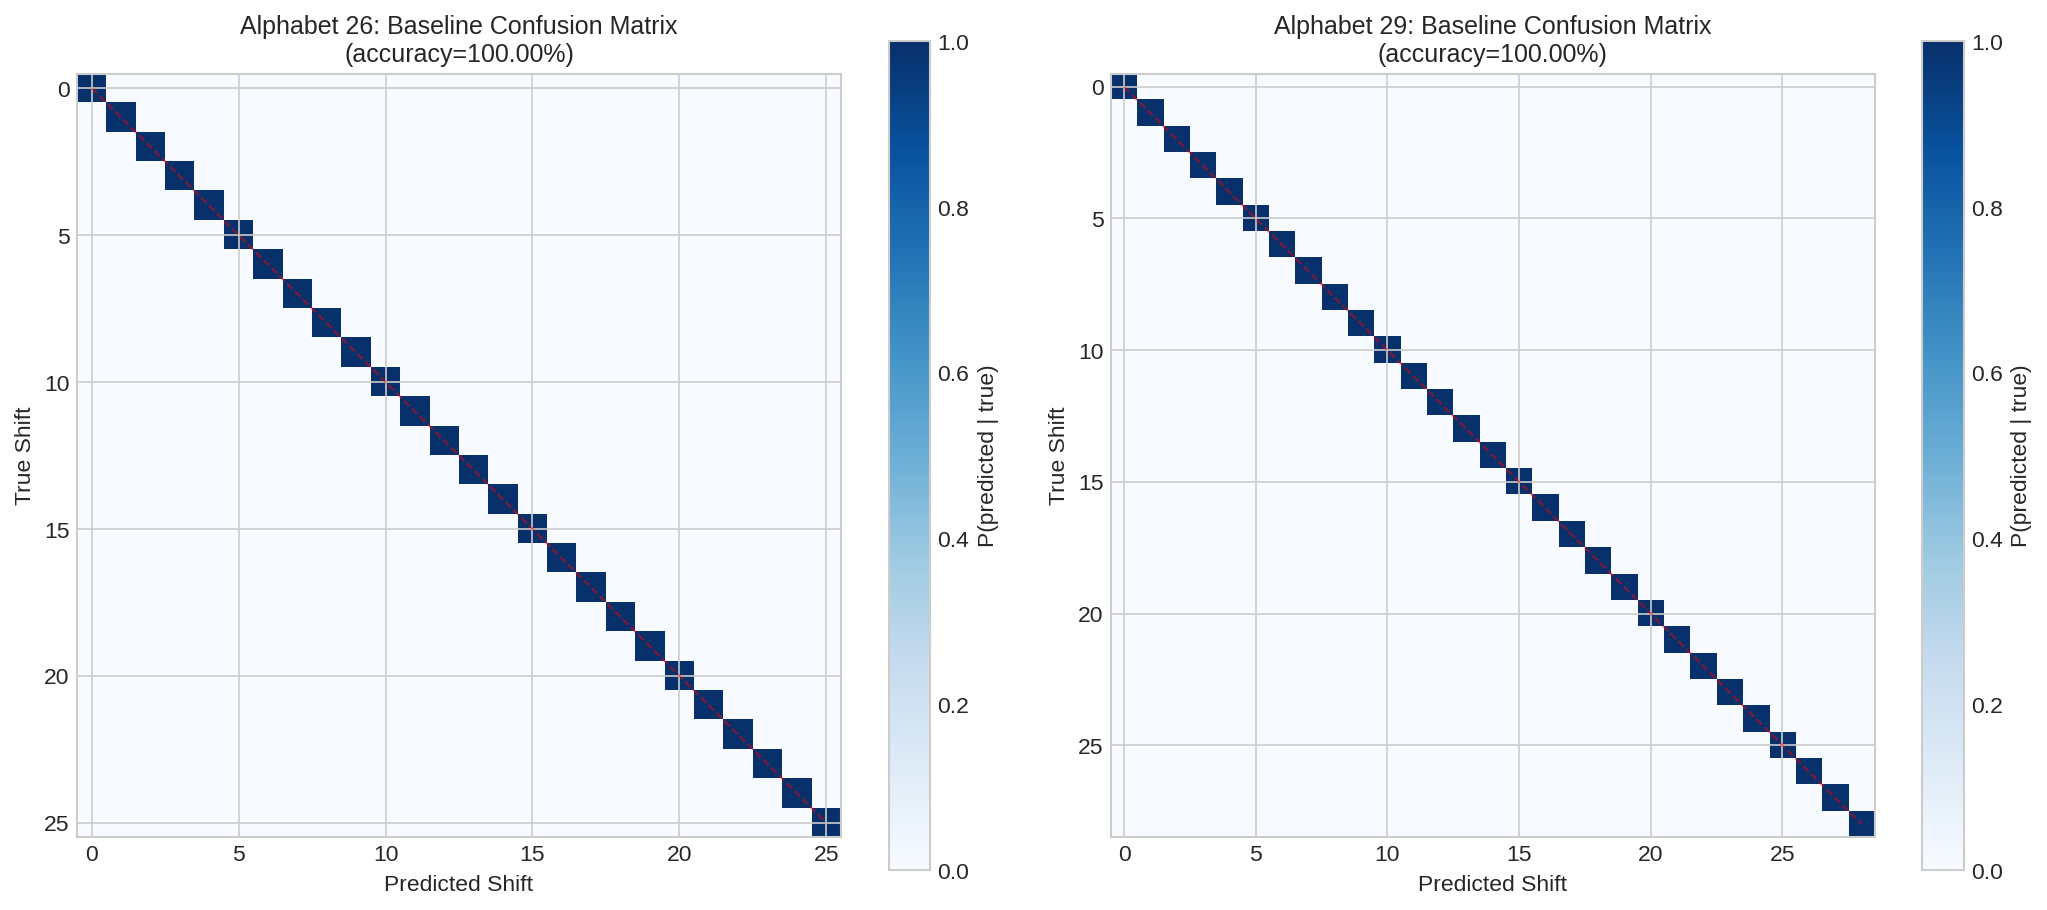

In [19]:
# Plot baseline confusion matrices
if baseline_26 is not None or baseline_29 is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    for ax, alph_size, baseline in zip(axes, [26, 29], [baseline_26, baseline_29]):
        if baseline is not None and 'confusion_matrix' in baseline:
            cm = baseline['confusion_matrix']
            # Normalize to get probabilities
            cm_normalized = cm / cm.sum(axis=1, keepdims=True)
            
            im = ax.imshow(cm_normalized, cmap='Blues', vmin=0, vmax=1, aspect='equal')
            ax.set_xlabel('Predicted Shift')
            ax.set_ylabel('True Shift')
            acc = baseline.get('overall_accuracy', 0)
            ax.set_title(f'Alphabet {alph_size}: Baseline Confusion Matrix\n(accuracy={acc:.2%})')
            plt.colorbar(im, ax=ax, label='P(predicted | true)')
            
            # Add diagonal line for reference
            ax.plot([0, alph_size-1], [0, alph_size-1], 'r--', alpha=0.5, linewidth=1)
        else:
            ax.set_title(f'Alphabet {alph_size}: No baseline data')
            ax.text(0.5, 0.5, 'Run baseline analysis first\nsbatch bash/sbatch_caesar_{}_baseline.sh'.format(alph_size),
                   ha='center', va='center', transform=ax.transAxes, fontsize=10)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
    
    plt.tight_layout()
    plt.savefig('figures/baseline_confusion_matrices.png', bbox_inches='tight', dpi=150)
    plt.show()
else:
    print("No baseline data available. Run the baseline analysis scripts first:")
    print("  sbatch bash/sbatch_caesar_26_baseline.sh")
    print("  sbatch bash/sbatch_caesar_29_baseline.sh")

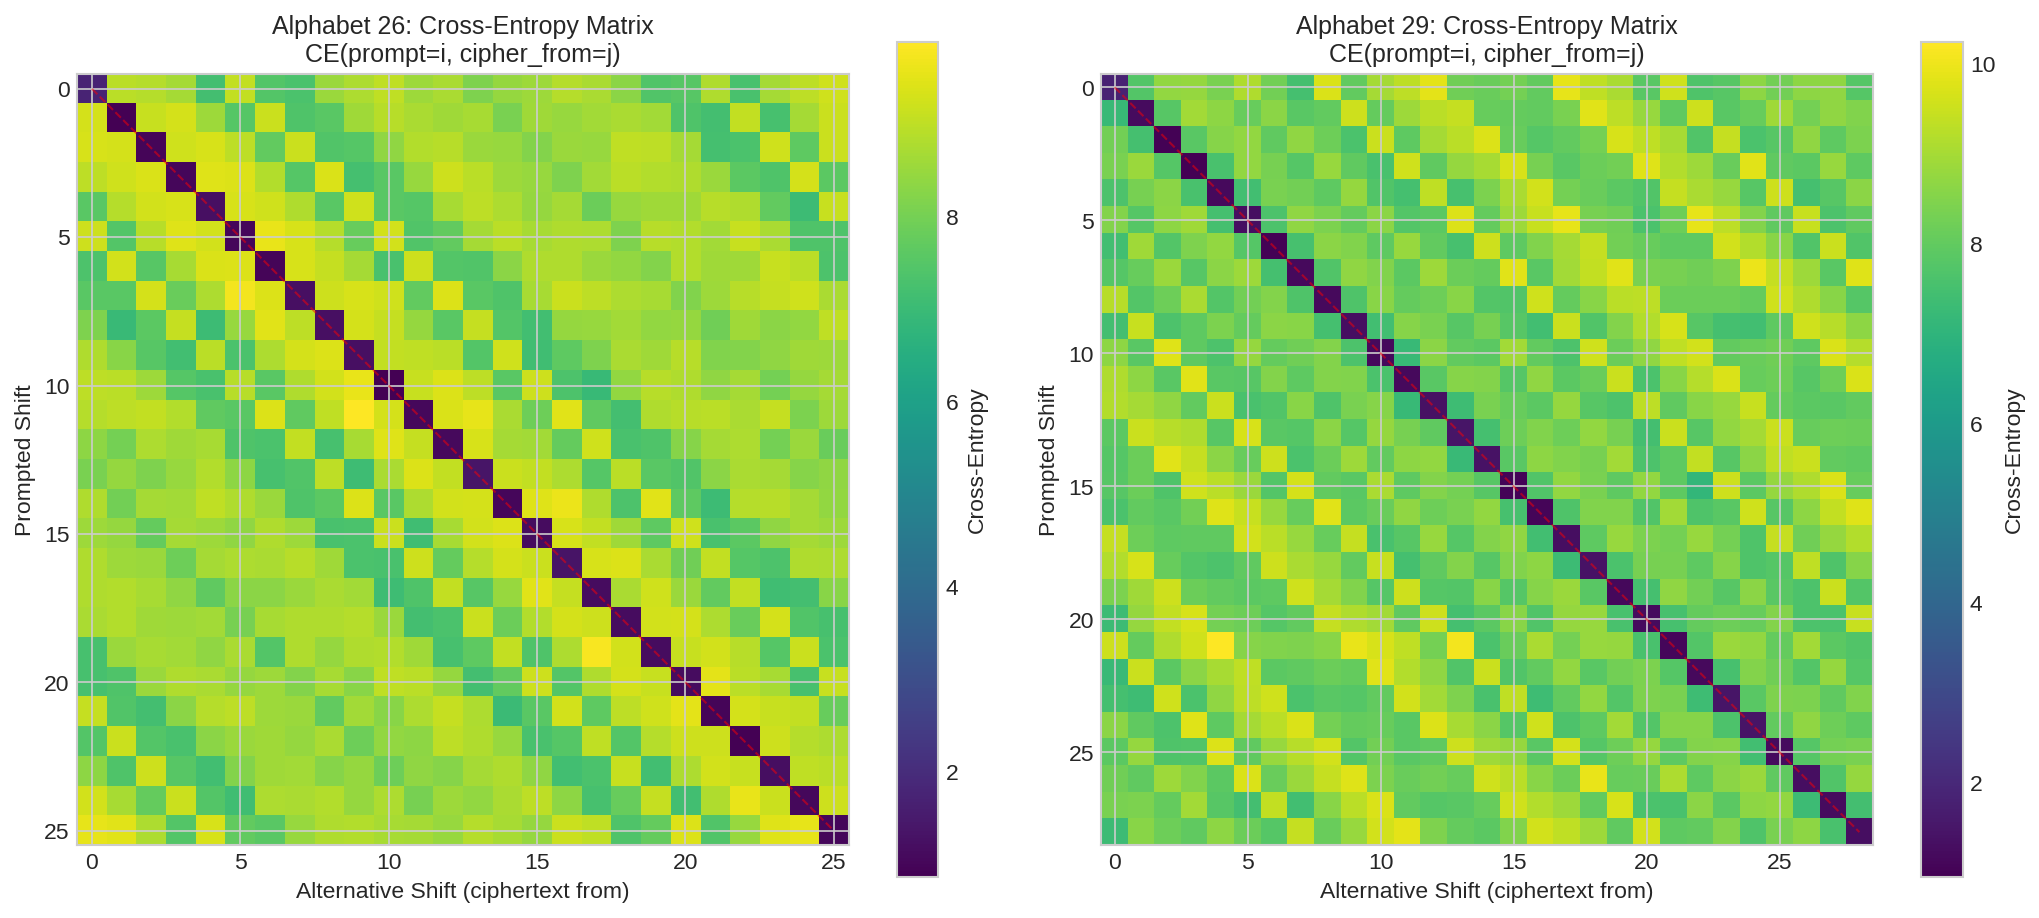


Interpretation:
  - Diagonal: CE when prompt matches ciphertext shift (should be LOW = model expects this)
  - Off-diagonal: CE when prompt doesn't match (should be HIGH = model surprised)
  - Structure in off-diagonal reveals which shift pairs the model confuses


In [20]:
# Plot baseline CE matrices (cross-entropy between shift pairs)
# CE[i,j] = cross-entropy when prompted with shift i but seeing ciphertext from shift j
if baseline_26 is not None or baseline_29 is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    for ax, alph_size, baseline in zip(axes, [26, 29], [baseline_26, baseline_29]):
        if baseline is not None and 'ce_matrix' in baseline:
            ce = baseline['ce_matrix']
            
            # Use diverging colormap centered on diagonal
            vmin, vmax = np.nanmin(ce), np.nanmax(ce)
            
            im = ax.imshow(ce, cmap='viridis', aspect='equal')
            ax.set_xlabel('Alternative Shift (ciphertext from)')
            ax.set_ylabel('Prompted Shift')
            ax.set_title(f'Alphabet {alph_size}: Cross-Entropy Matrix\nCE(prompt=i, cipher_from=j)')
            plt.colorbar(im, ax=ax, label='Cross-Entropy')
            
            # Add diagonal line
            ax.plot([0, alph_size-1], [0, alph_size-1], 'r--', alpha=0.5, linewidth=1)
        else:
            ax.set_title(f'Alphabet {alph_size}: No CE data')
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
    
    plt.tight_layout()
    plt.savefig('figures/baseline_ce_matrices.png', bbox_inches='tight', dpi=150)
    plt.show()
    
    # Print interpretation
    print("\nInterpretation:")
    print("  - Diagonal: CE when prompt matches ciphertext shift (should be LOW = model expects this)")
    print("  - Off-diagonal: CE when prompt doesn't match (should be HIGH = model surprised)")
    print("  - Structure in off-diagonal reveals which shift pairs the model confuses")

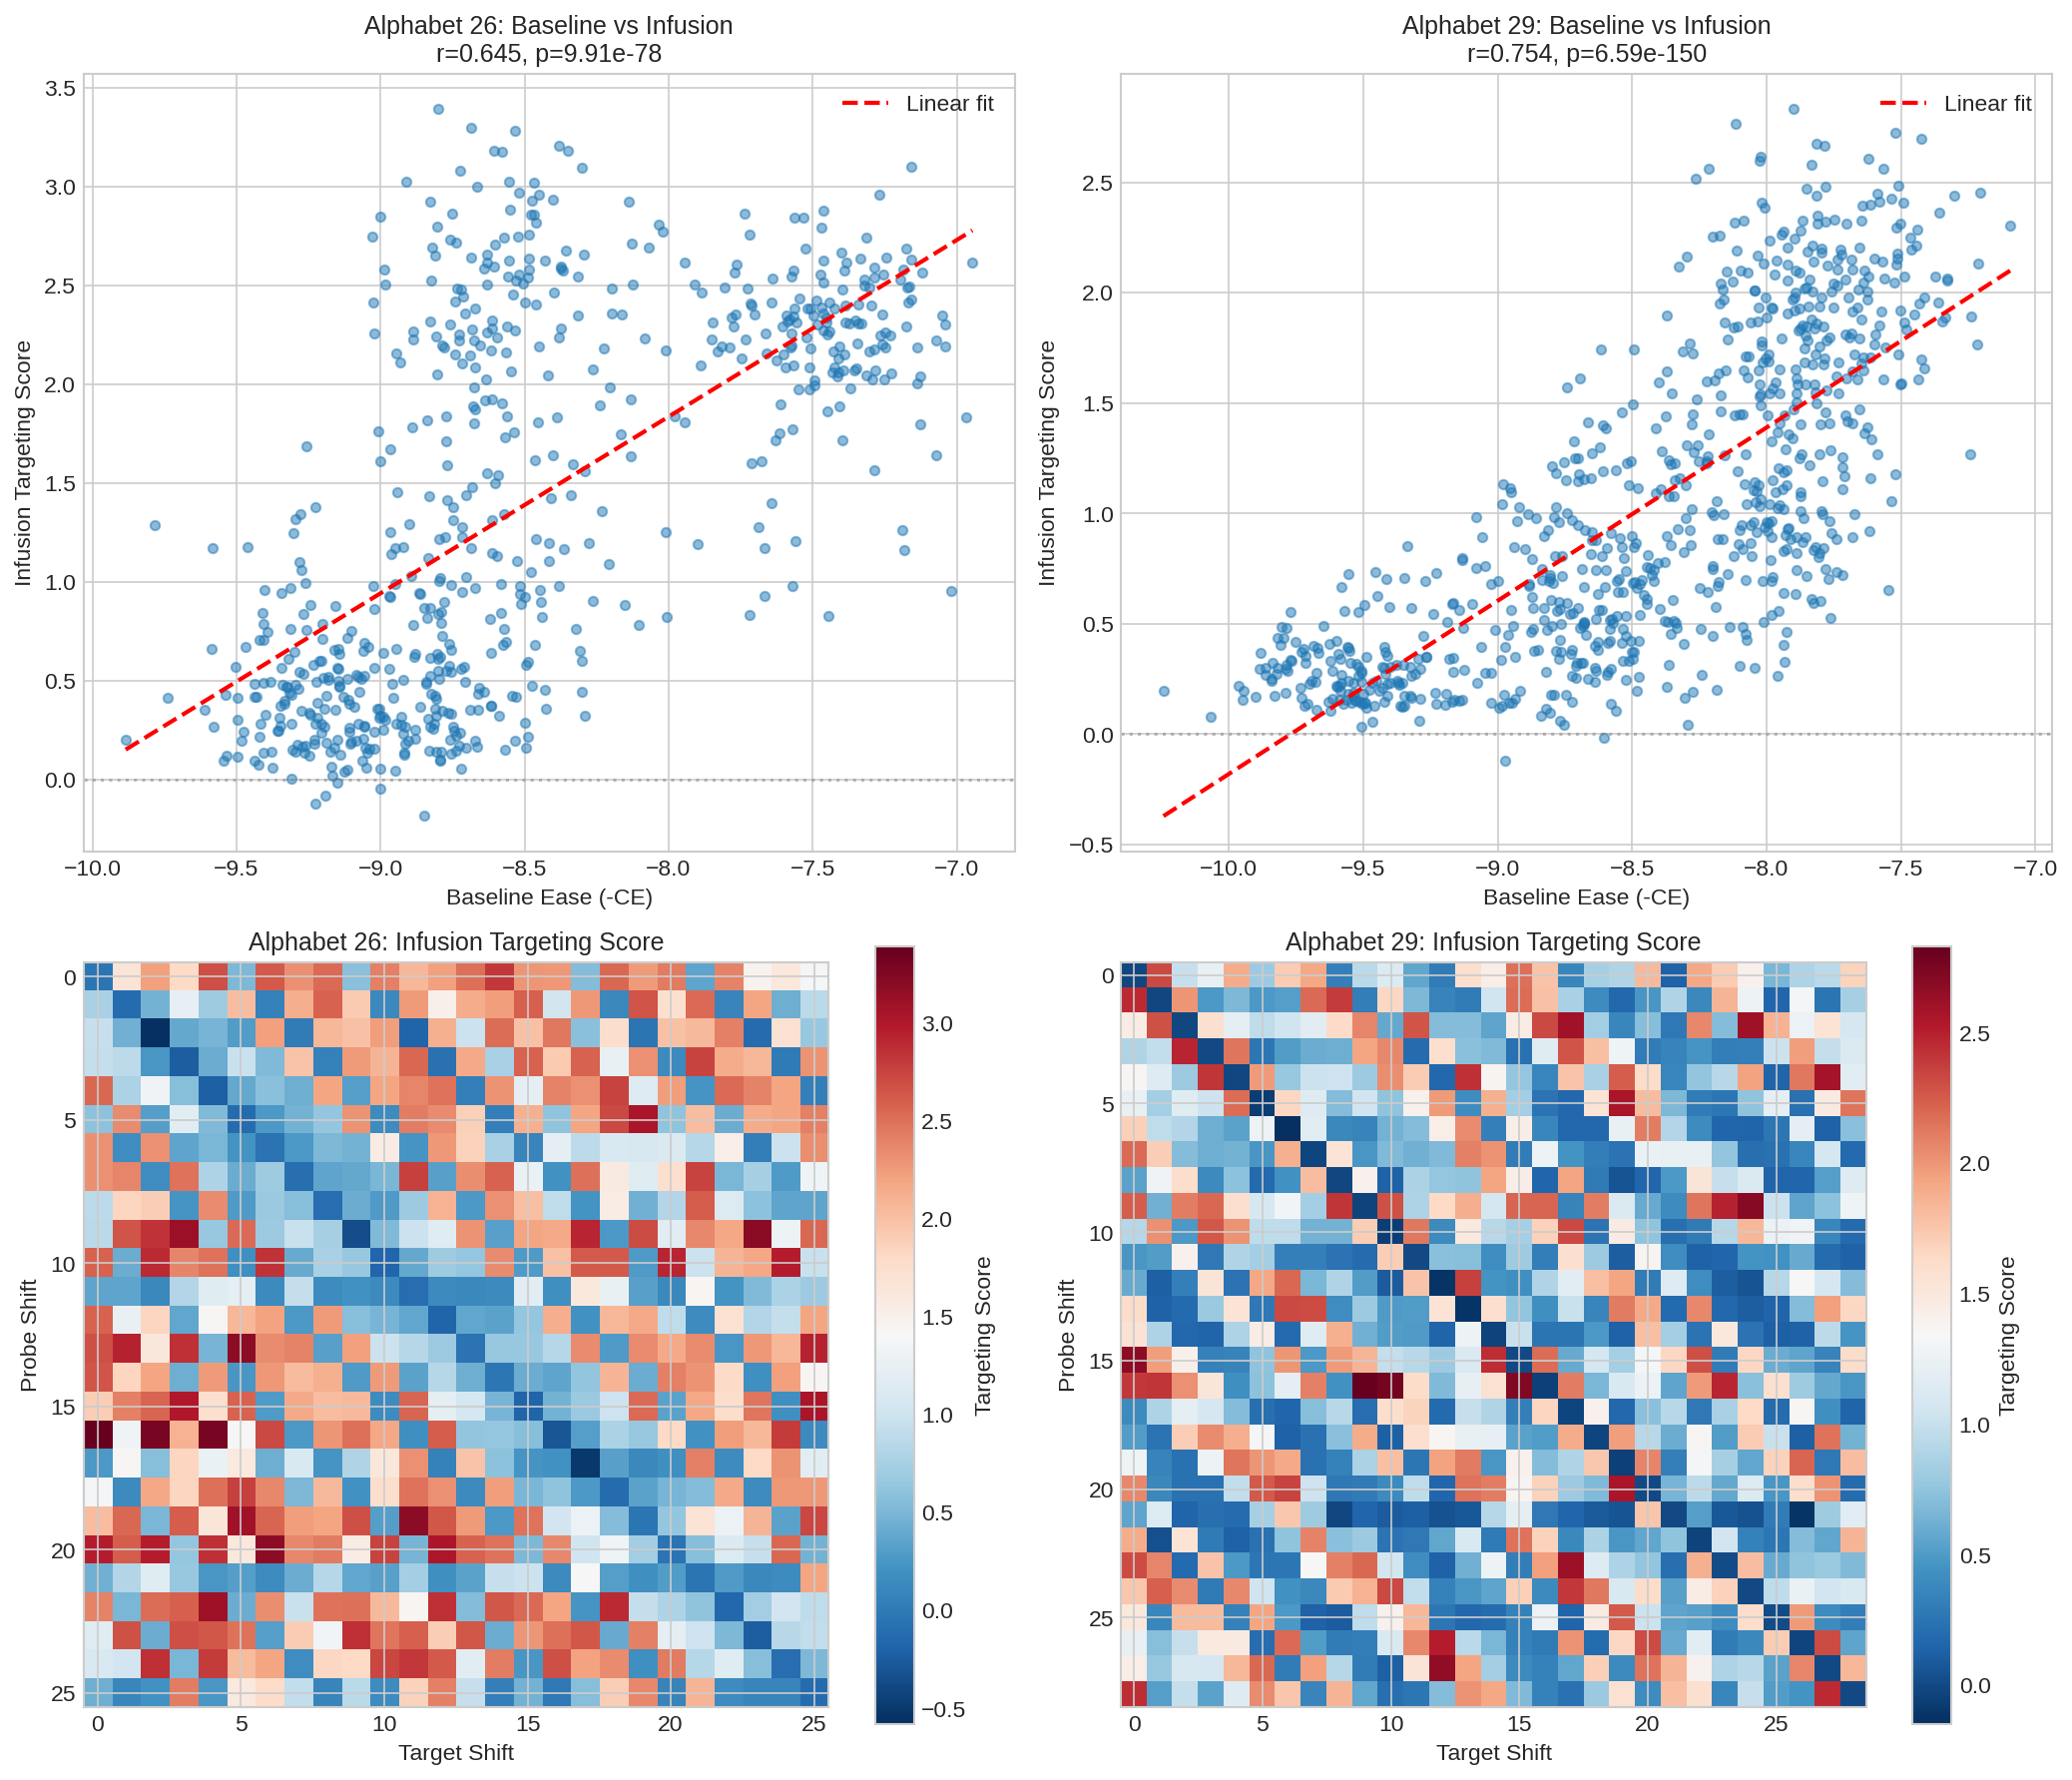


BASELINE vs INFUSION CORRELATION ANALYSIS

Question: Does baseline model confusion predict infusion success?
  - If correlated: Infusion exploits existing model weaknesses
  - If uncorrelated: Infusion creates new vulnerabilities


In [21]:
# Compare baseline confusion with infusion targeting scores
# Key question: Does the baseline model's confusion predict infusion success?

if baseline_26 is not None and len(df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    for col, (alph_size, baseline) in enumerate([(26, baseline_26), (29, baseline_29)]):
        if baseline is None or 'ce_matrix' not in baseline:
            continue
            
        ce_matrix = baseline['ce_matrix']
        df_alph = df[df['alphabet_size'] == alph_size]
        
        if len(df_alph) == 0:
            continue
        
        # Build targeting score matrix from infusion results
        targeting_matrix = np.full((alph_size, alph_size), np.nan)
        for _, row in df_alph.iterrows():
            p, t = int(row['probe_shift']), int(row['target_shift'])
            targeting_matrix[p, t] = row['targeting_score']
        
        # Plot 1: Side-by-side comparison
        ax = axes[0, col]
        
        # Compute baseline "ease of confusion" = -CE (lower CE = easier to confuse)
        # or we can use the off-diagonal CE normalized
        baseline_ease = -ce_matrix  # Negative CE: higher = easier to get model to accept wrong shift
        
        # Flatten both matrices (excluding diagonal)
        mask = ~np.eye(alph_size, dtype=bool)
        baseline_flat = baseline_ease[mask]
        targeting_flat = targeting_matrix[mask]
        
        # Remove NaN
        valid = ~np.isnan(targeting_flat)
        baseline_flat = baseline_flat[valid]
        targeting_flat = targeting_flat[valid]
        
        # Scatter plot with correlation
        ax.scatter(baseline_flat, targeting_flat, alpha=0.5, s=20)
        
        # Compute correlation
        if len(baseline_flat) > 2:
            corr, p_val = stats.pearsonr(baseline_flat, targeting_flat)
            ax.set_title(f'Alphabet {alph_size}: Baseline vs Infusion\nr={corr:.3f}, p={p_val:.2e}')
            
            # Add trend line
            z = np.polyfit(baseline_flat, targeting_flat, 1)
            p_line = np.poly1d(z)
            x_line = np.linspace(baseline_flat.min(), baseline_flat.max(), 100)
            ax.plot(x_line, p_line(x_line), 'r--', linewidth=2, label=f'Linear fit')
        else:
            ax.set_title(f'Alphabet {alph_size}: Insufficient data')
        
        ax.set_xlabel('Baseline Ease (-CE)')
        ax.set_ylabel('Infusion Targeting Score')
        ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
        ax.legend()
        
        # Plot 2: Heatmap comparison (difference)
        ax = axes[1, col]
        
        # Normalize both to same scale for comparison
        baseline_norm = (baseline_ease - np.nanmean(baseline_ease)) / np.nanstd(baseline_ease)
        targeting_norm = (targeting_matrix - np.nanmean(targeting_matrix)) / np.nanstd(targeting_matrix)
        
        # Show targeting score heatmap with baseline-predicted overlay
        im = ax.imshow(targeting_matrix, cmap='RdBu_r', aspect='equal')
        ax.set_xlabel('Target Shift')
        ax.set_ylabel('Probe Shift')
        ax.set_title(f'Alphabet {alph_size}: Infusion Targeting Score')
        plt.colorbar(im, ax=ax, label='Targeting Score')
    
    plt.tight_layout()
    plt.savefig('figures/baseline_vs_infusion_comparison.png', bbox_inches='tight', dpi=150)
    plt.show()
    
    # Print correlation summary
    print("\n" + "="*60)
    print("BASELINE vs INFUSION CORRELATION ANALYSIS")
    print("="*60)
    print("\nQuestion: Does baseline model confusion predict infusion success?")
    print("  - If correlated: Infusion exploits existing model weaknesses")
    print("  - If uncorrelated: Infusion creates new vulnerabilities")
else:
    print("Need both baseline and infusion data for comparison.")
    print("Run baseline analysis first if not available.")

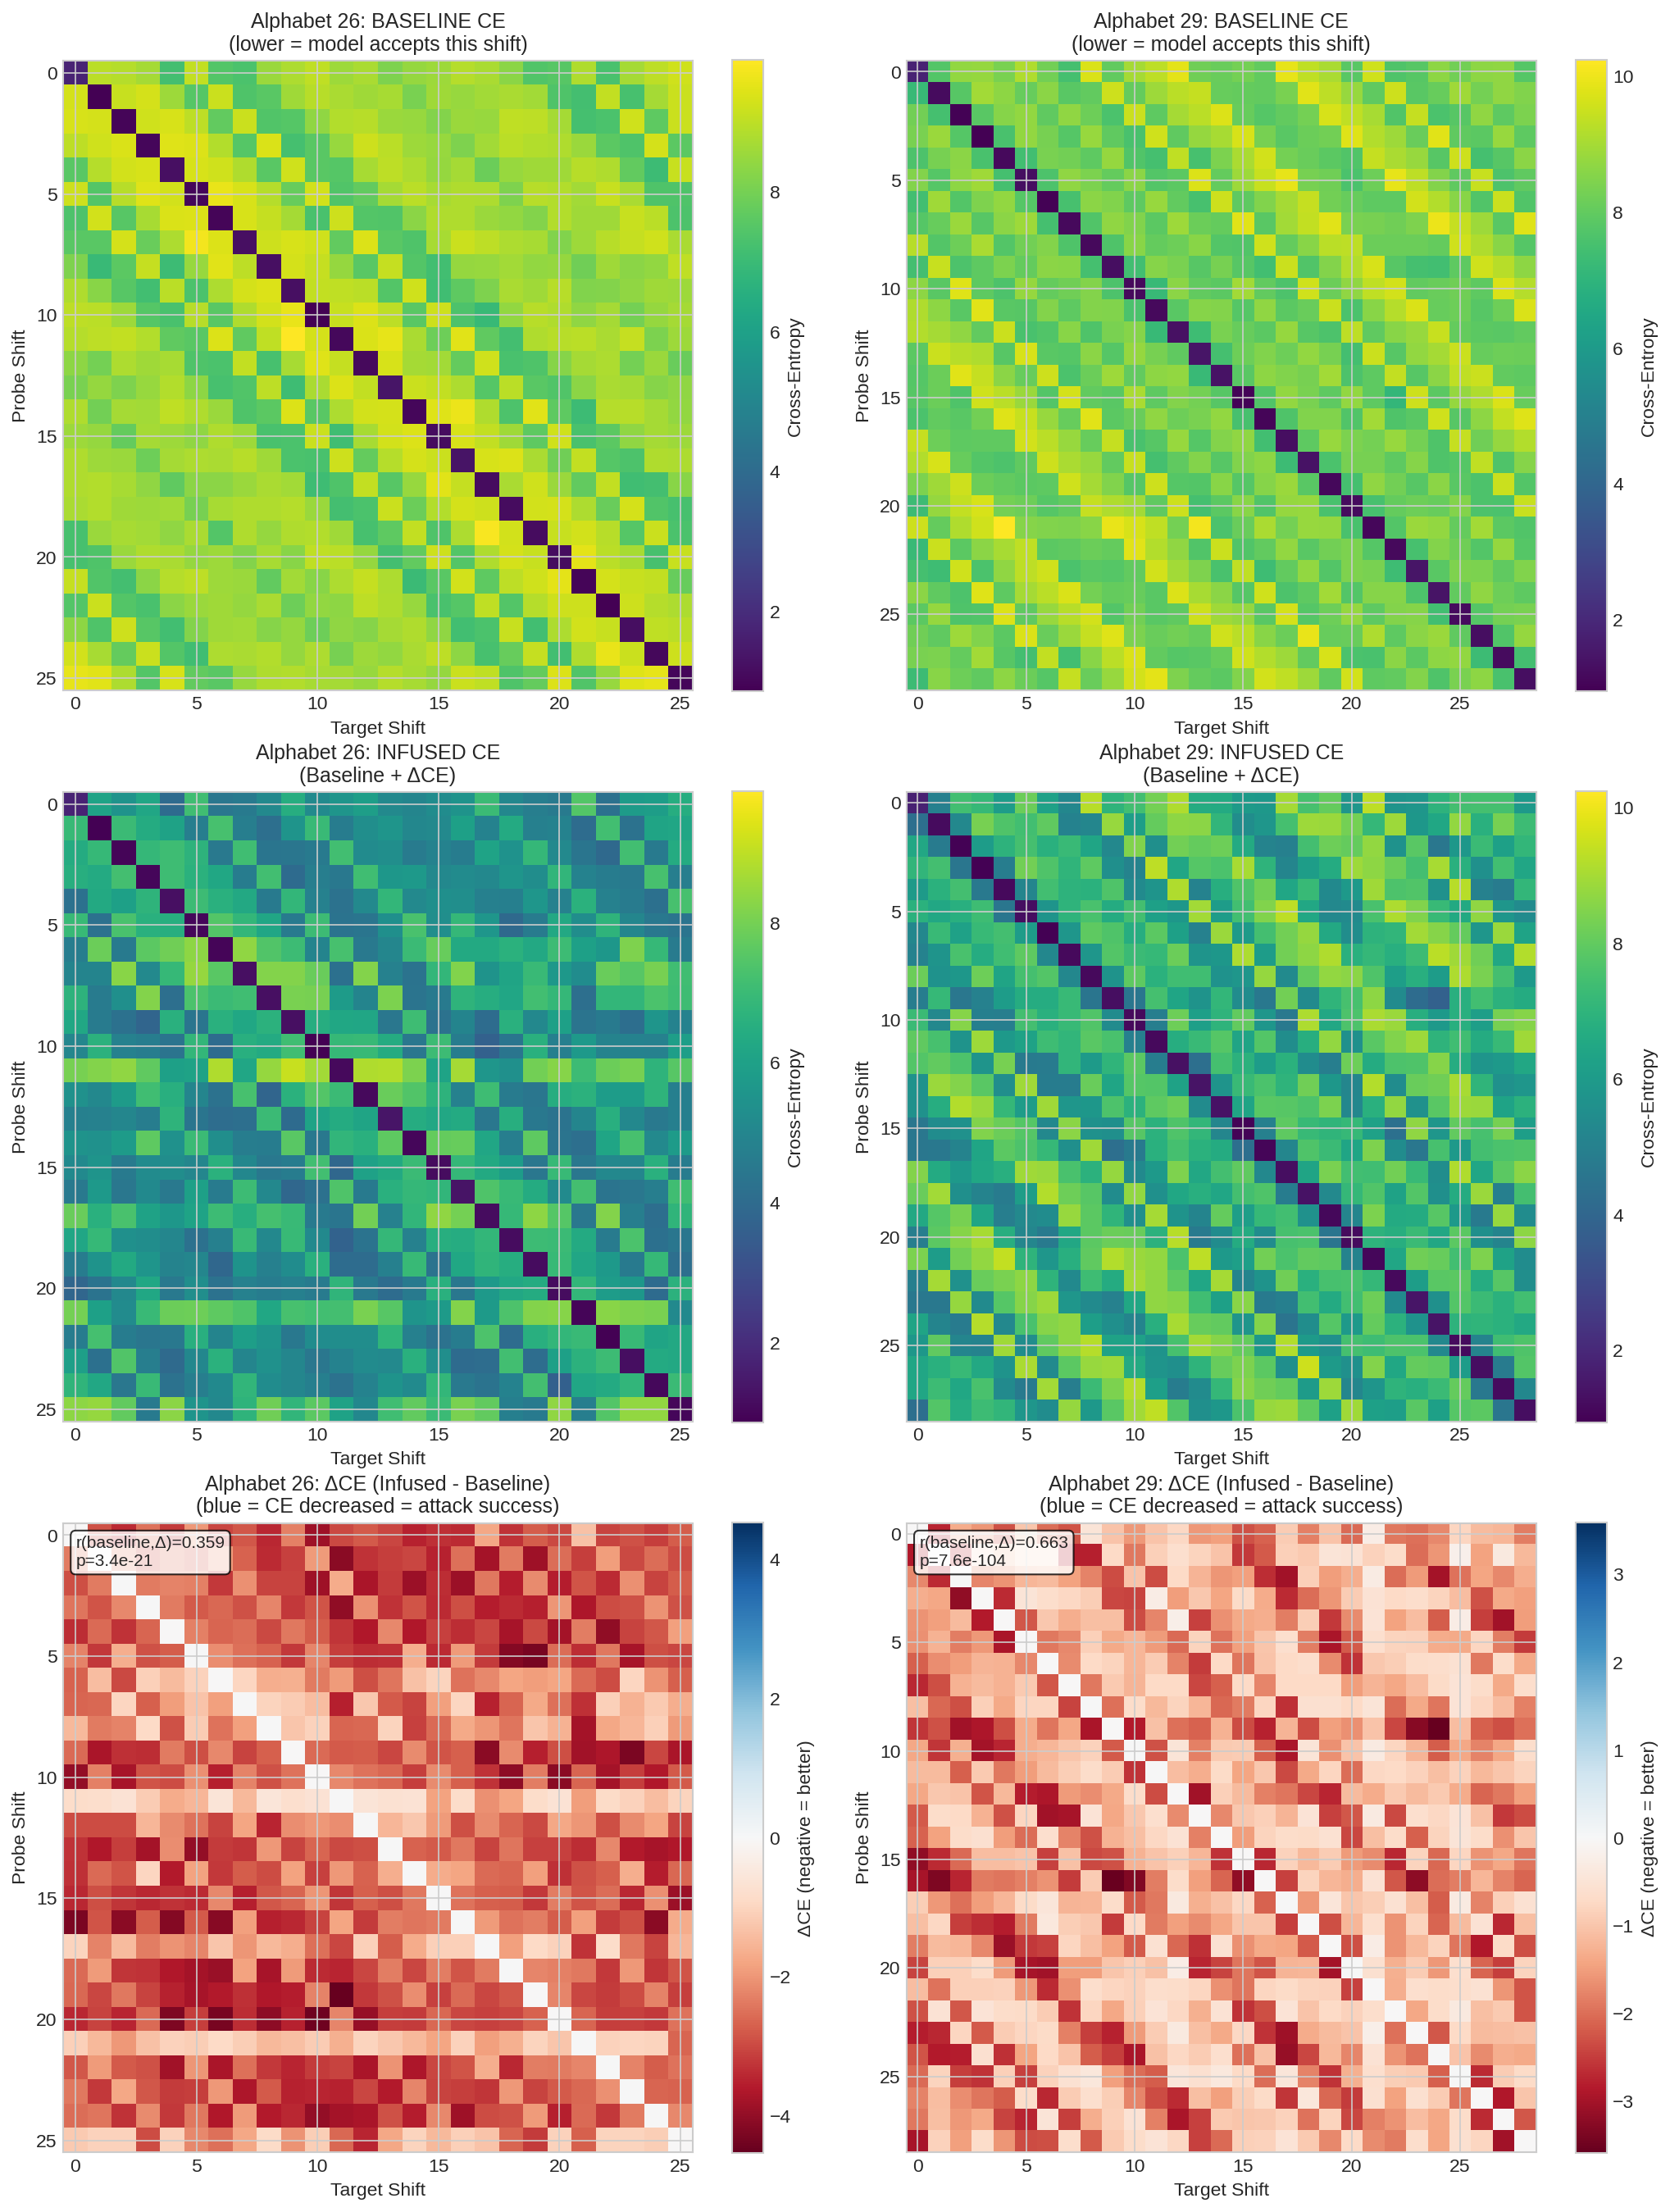


INTERPRETATION (All metrics in Cross-Entropy)

Row 1 (BASELINE CE): Cross-entropy of uninfused model for each (probe, target) pair.
    - Lower CE = model more willing to produce this target shift
    - Diagonal should be lowest (correct shift)

Row 2 (INFUSED CE): Cross-entropy after infusion = Baseline + ΔCE.
    - Shows how model behaves after the attack
    - Compare to Row 1 to see attack effect

Row 3 (ΔCE): The change in CE caused by infusion.
    - Blue (negative) = CE decreased = model now MORE confident at target = ATTACK SUCCESS
    - Red (positive) = CE increased = model now LESS confident at target = attack failed
    - Correlation r(baseline, Δ) shows if high-CE pairs are easier to attack



In [24]:
# 3x2 Comparison Grid: Baseline CE vs Infused CE vs Delta CE
# All rows use Cross-Entropy for direct comparison
# Row 1: Baseline CE matrix (uninfused model)
# Row 2: Infused CE matrix (baseline + delta_ce_target)
# Row 3: Delta CE (change caused by infusion)

if (baseline_26 is not None or baseline_29 is not None) and len(df) > 0:
    fig, axes = plt.subplots(3, 2, figsize=(14, 18))

    for col, (alph_size, baseline) in enumerate([(26, baseline_26), (29, baseline_29)]):
        df_alph = df[df['alphabet_size'] == alph_size]

        # Build delta_ce_target matrix from infusion results
        delta_ce_matrix = np.full((alph_size, alph_size), np.nan)
        if len(df_alph) > 0:
            for _, row in df_alph.iterrows():
                p, t = int(row['probe_shift']), int(row['target_shift'])
                delta_ce_matrix[p, t] = row['delta_ce_target']

        # ===== ROW 1: Baseline CE Matrix =====
        ax = axes[0, col]
        if baseline is not None and 'ce_matrix' in baseline:
            ce_matrix = baseline['ce_matrix']

            # Get color scale from baseline
            vmin_ce, vmax_ce = np.nanmin(ce_matrix), np.nanmax(ce_matrix)

            im = ax.imshow(ce_matrix, cmap='viridis', vmin=vmin_ce, vmax=vmax_ce, aspect='equal')
            ax.set_xlabel('Target Shift')
            ax.set_ylabel('Probe Shift')
            ax.set_title(f'Alphabet {alph_size}: BASELINE CE\n(lower = model accepts this shift)')
            plt.colorbar(im, ax=ax, label='Cross-Entropy')
        else:
            ax.text(0.5, 0.5, f'No baseline data\nRun sbatch_caesar_{alph_size}_baseline.sh',
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'Alphabet {alph_size}: BASELINE CE')

        # ===== ROW 2: Infused CE Matrix (Baseline + Delta) =====
        ax = axes[1, col]
        if baseline is not None and 'ce_matrix' in baseline and len(df_alph) > 0:
            # Infused CE = Baseline CE + delta_ce_target
            infused_ce_matrix = ce_matrix + delta_ce_matrix

            im = ax.imshow(infused_ce_matrix, cmap='viridis', vmin=vmin_ce, vmax=vmax_ce, aspect='equal')
            ax.set_xlabel('Target Shift')
            ax.set_ylabel('Probe Shift')
            ax.set_title(f'Alphabet {alph_size}: INFUSED CE\n(Baseline + ΔCE)')
            plt.colorbar(im, ax=ax, label='Cross-Entropy')
        else:
            ax.text(0.5, 0.5, 'Need both baseline and infusion data',
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'Alphabet {alph_size}: INFUSED CE')

        # ===== ROW 3: Delta CE (the change) =====
        ax = axes[2, col]
        if len(df_alph) > 0:
            # delta_ce_target: negative = attack reduced CE (model more confident at target)
            vabs = max(abs(np.nanmin(delta_ce_matrix)), abs(np.nanmax(delta_ce_matrix)))
            im = ax.imshow(delta_ce_matrix, cmap='RdBu', vmin=-vabs, vmax=vabs, aspect='equal')
            ax.set_xlabel('Target Shift')
            ax.set_ylabel('Probe Shift')
            ax.set_title(f'Alphabet {alph_size}: ΔCE (Infused - Baseline)\n(blue = CE decreased = attack success)')
            plt.colorbar(im, ax=ax, label='ΔCE (negative = better)')

            # Compute correlation between baseline CE and delta CE
            if baseline is not None and 'ce_matrix' in baseline:
                mask = ~np.eye(alph_size, dtype=bool) & ~np.isnan(delta_ce_matrix)
                corr, p_val = stats.pearsonr(ce_matrix[mask], delta_ce_matrix[mask])
                ax.text(0.02, 0.98, f'r(baseline,Δ)={corr:.3f}\np={p_val:.1e}',
                       transform=ax.transAxes, va='top', ha='left',
                       fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        else:
            ax.text(0.5, 0.5, 'No infusion data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'Alphabet {alph_size}: ΔCE')

    plt.tight_layout()
    plt.savefig('figures/baseline_infusion_ce_comparison.png', bbox_inches='tight', dpi=150)
    plt.show()

    # Print interpretation
    print("\n" + "="*70)
    print("INTERPRETATION (All metrics in Cross-Entropy)")
    print("="*70)
    print("""
Row 1 (BASELINE CE): Cross-entropy of uninfused model for each (probe, target) pair.
    - Lower CE = model more willing to produce this target shift
    - Diagonal should be lowest (correct shift)

Row 2 (INFUSED CE): Cross-entropy after infusion = Baseline + ΔCE.
    - Shows how model behaves after the attack
    - Compare to Row 1 to see attack effect

Row 3 (ΔCE): The change in CE caused by infusion.
    - Blue (negative) = CE decreased = model now MORE confident at target = ATTACK SUCCESS
    - Red (positive) = CE increased = model now LESS confident at target = attack failed
    - Correlation r(baseline, Δ) shows if high-CE pairs are easier to attack
""")
else:
    print("Need both baseline and infusion data for comparison grid.")
    print("Run baseline analysis scripts first if not available.")

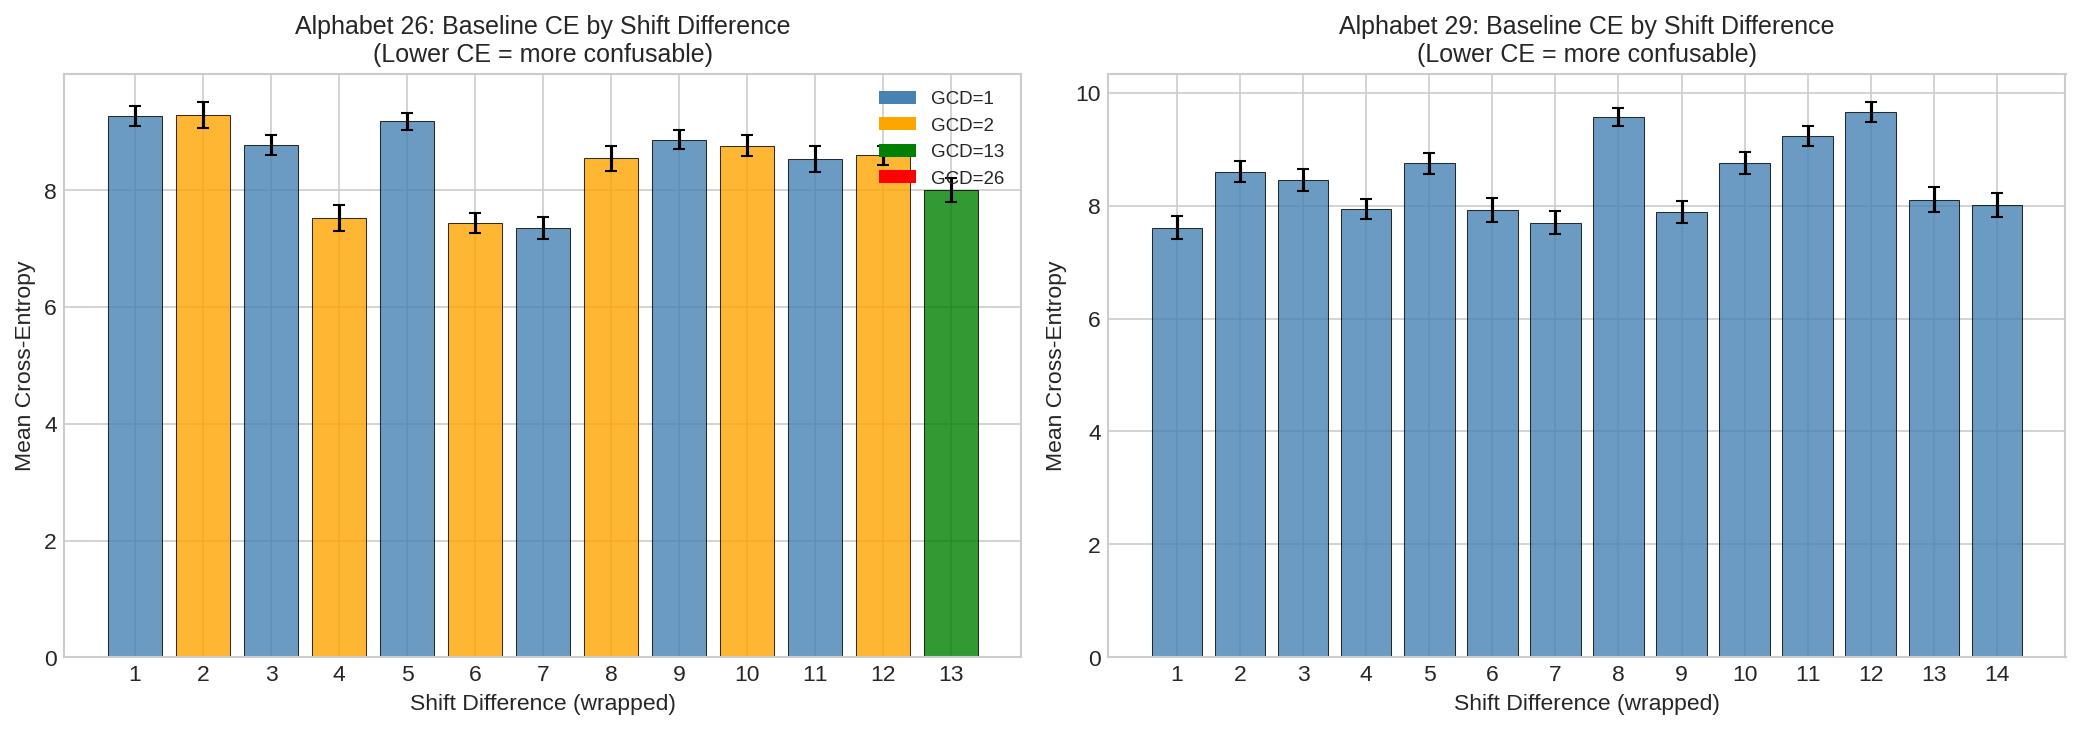


BASELINE GCD ANALYSIS

Question: Does the uninfused model already confuse shifts with shared factors?
  - If yes: GCD structure is learned during training
  - If no: Infusion introduces GCD-related vulnerabilities


In [23]:
# GCD analysis on baseline data
# Does the baseline model show GCD-related confusion patterns?

if baseline_26 is not None and 'ce_matrix' in baseline_26:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for ax, (alph_size, baseline) in zip(axes, [(26, baseline_26), (29, baseline_29)]):
        if baseline is None or 'ce_matrix' not in baseline:
            ax.set_title(f'Alphabet {alph_size}: No data')
            continue
            
        ce_matrix = baseline['ce_matrix']
        
        # For each shift difference, compute mean CE (excluding diagonal)
        shift_diff_ce = {}
        for i in range(alph_size):
            for j in range(alph_size):
                if i != j:
                    # Wrapped shift difference
                    diff_raw = abs(j - i)
                    diff = min(diff_raw, alph_size - diff_raw)
                    
                    if diff not in shift_diff_ce:
                        shift_diff_ce[diff] = []
                    shift_diff_ce[diff].append(ce_matrix[i, j])
        
        # Compute means and color by GCD
        shifts = sorted(shift_diff_ce.keys())
        means = [np.mean(shift_diff_ce[s]) for s in shifts]
        stds = [np.std(shift_diff_ce[s]) for s in shifts]
        
        if alph_size == 26:
            colors = ['steelblue' if math.gcd(s, 26) == 1 else 
                     'orange' if math.gcd(s, 26) == 2 else
                     'green' if math.gcd(s, 26) == 13 else 'red'
                     for s in shifts]
        else:
            colors = ['steelblue' if s != 0 else 'red' for s in shifts]
        
        ax.bar(shifts, means, yerr=stds, capsize=3, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
        ax.set_xlabel('Shift Difference (wrapped)')
        ax.set_ylabel('Mean Cross-Entropy')
        ax.set_title(f'Alphabet {alph_size}: Baseline CE by Shift Difference\n(Lower CE = more confusable)')
        ax.set_xticks(shifts)
        
        if alph_size == 26:
            from matplotlib.patches import Patch
            legend_elements = [Patch(facecolor='steelblue', label='GCD=1'),
                             Patch(facecolor='orange', label='GCD=2'),
                             Patch(facecolor='green', label='GCD=13'),
                             Patch(facecolor='red', label='GCD=26')]
            ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('figures/baseline_gcd_analysis.png', bbox_inches='tight', dpi=150)
    plt.show()
    
    # Print analysis
    print("\n" + "="*60)
    print("BASELINE GCD ANALYSIS")
    print("="*60)
    print("\nQuestion: Does the uninfused model already confuse shifts with shared factors?")
    print("  - If yes: GCD structure is learned during training")
    print("  - If no: Infusion introduces GCD-related vulnerabilities")
else:
    print("Need baseline data for GCD analysis.")

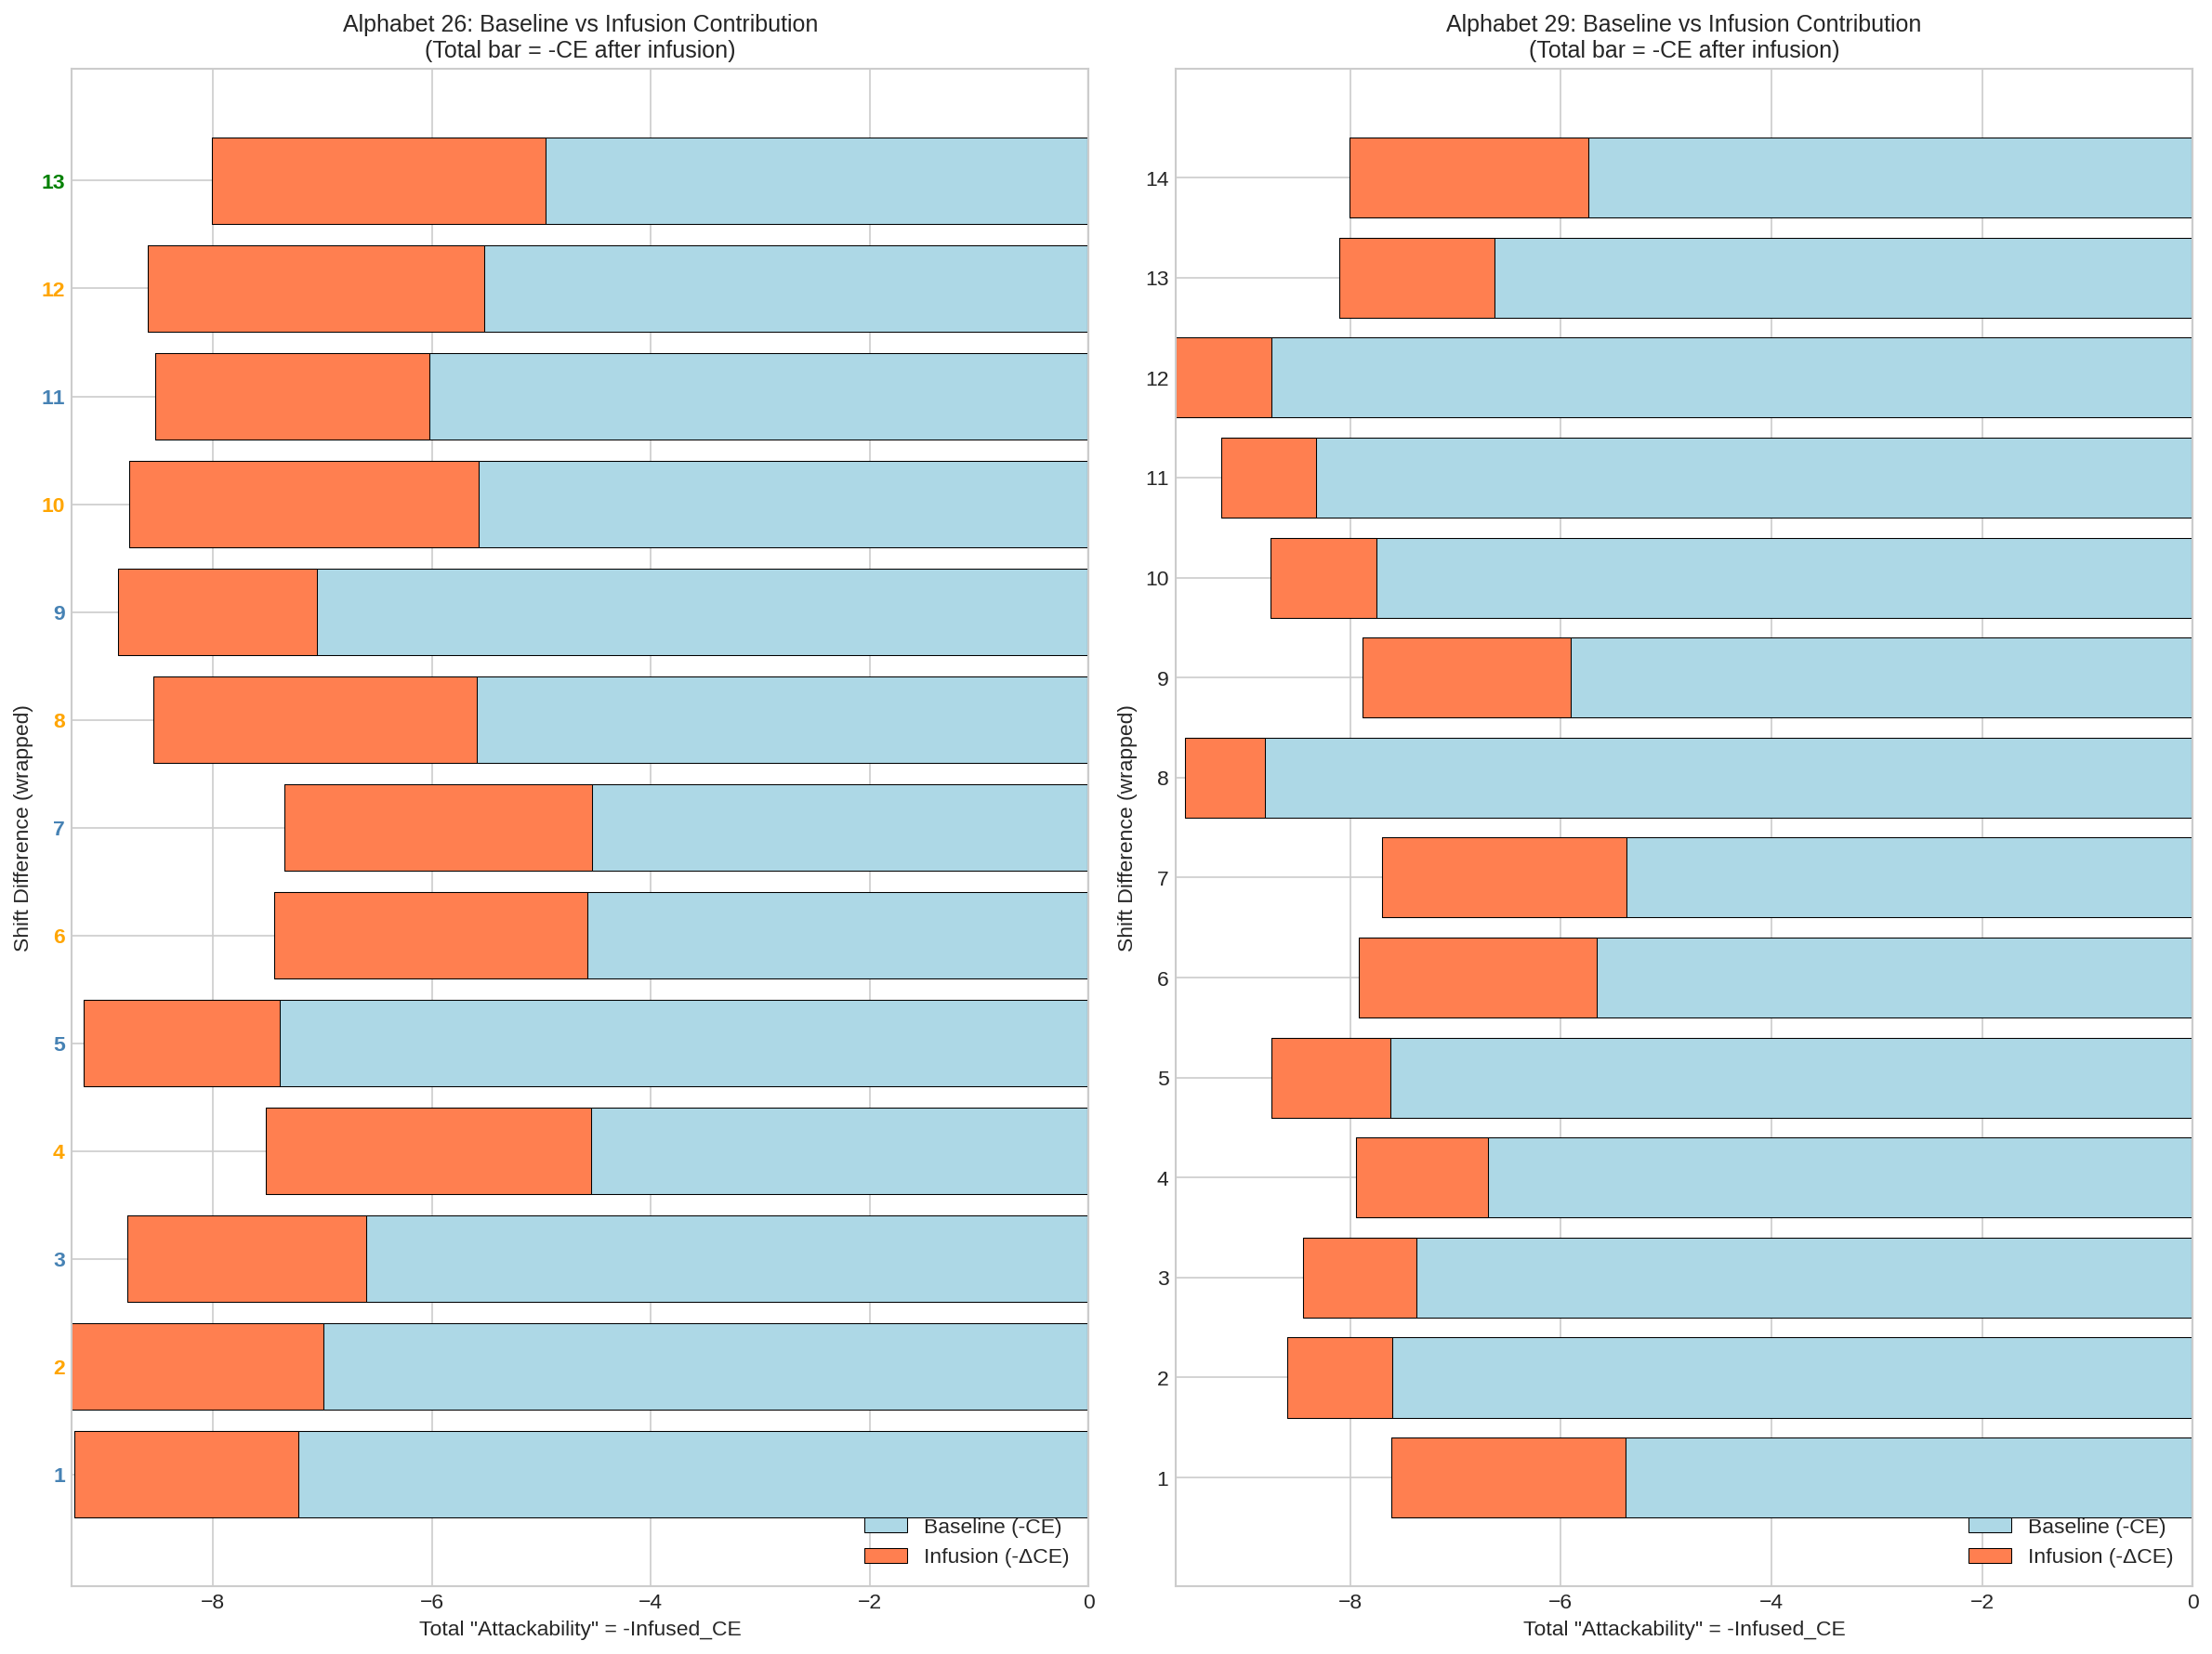


STACKED BAR INTERPRETATION

Light Blue (Baseline -CE): How "attackable" the shift was before infusion.
    - Higher = model already confused about this shift difference
    
Coral (Infusion -ΔCE): Additional attackability from infusion.
    - Positive = infusion reduced CE (attack success)
    - Negative = infusion increased CE (attack backfired)
    
Total bar length = -CE after infusion = how confused the model is now.

Key insight: Compare the coral portions between alphabets.
    - Larger coral = infusion had bigger effect
    - If coral is similar but baseline differs → baseline structure matters



In [30]:
# Stacked bar chart: Baseline vs Infusion contribution to "attackability"
# Total -CE = (-Baseline_CE) + (-delta_ce_target)
# This shows how much of the final model's confusion comes from baseline vs infusion

if (baseline_26 is not None or baseline_29 is not None) and len(df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 12))
    
    for ax, (alph_size, baseline) in zip(axes, [(26, baseline_26), (29, baseline_29)]):
        if baseline is None or 'ce_matrix' not in baseline:
            ax.set_title(f'Alphabet {alph_size}: No baseline data')
            continue
            
        df_alph = df[df['alphabet_size'] == alph_size]
        if len(df_alph) == 0:
            continue
            
        ce_matrix = baseline['ce_matrix']
        
        # Compute baseline and infusion contributions by shift difference
        shift_data = {}
        for i in range(alph_size):
            for j in range(alph_size):
                if i != j:  # Exclude diagonal
                    diff_raw = abs(j - i)
                    diff = min(diff_raw, alph_size - diff_raw)
                    
                    if diff not in shift_data:
                        shift_data[diff] = {'baseline': [], 'delta': []}
                    
                    # Baseline contribution: -CE (higher = more confusable)
                    shift_data[diff]['baseline'].append(-ce_matrix[i, j])
                    
                    # Get delta_ce_target from infusion results
                    row = df_alph[(df_alph['probe_shift'] == i) & (df_alph['target_shift'] == j)]
                    if len(row) > 0:
                        # Infusion contribution: -delta_ce (positive delta_ce means CE increased)
                        # We want -delta_ce so that negative delta (attack success) shows as positive bar
                        shift_data[diff]['delta'].append(-row['delta_ce_target'].values[0])
        
        # Compute means
        shifts = sorted(shift_data.keys())
        baseline_means = [np.mean(shift_data[s]['baseline']) for s in shifts]
        delta_means = [np.mean(shift_data[s]['delta']) for s in shifts]
        
        # Create stacked horizontal bar chart
        y_pos = np.arange(len(shifts))
        
        # Baseline portion (always positive since -CE of wrong shifts is high)
        bars1 = ax.barh(y_pos, baseline_means, label='Baseline (-CE)', 
                       color='lightblue', edgecolor='black', linewidth=0.5)
        
        # Infusion portion (stacked on top)
        # Note: delta_means will be positive when attack succeeded (CE decreased, so -delta is positive)
        bars2 = ax.barh(y_pos, delta_means, left=baseline_means, label='Infusion (-ΔCE)',
                       color='coral', edgecolor='black', linewidth=0.5)
        
        ax.axvline(0, color='black', linestyle='-', linewidth=1)
        ax.set_ylabel('Shift Difference (wrapped)')
        ax.set_xlabel('Total "Attackability" = -Infused_CE')
        ax.set_title(f'Alphabet {alph_size}: Baseline vs Infusion Contribution\n(Total bar = -CE after infusion)')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(shifts)
        ax.legend(loc='lower right')
        
        # Add GCD coloring to y-axis labels
        if alph_size == 26:
            gcd_colors = {1: 'steelblue', 2: 'orange', 13: 'green', 26: 'red'}
            for i, shift in enumerate(shifts):
                gcd = math.gcd(int(shift), 26)
                ax.get_yticklabels()[i].set_color(gcd_colors.get(gcd, 'black'))
                ax.get_yticklabels()[i].set_fontweight('bold')
    
    plt.tight_layout()
    plt.savefig('figures/baseline_vs_infusion_stacked.png', bbox_inches='tight', dpi=150)
    plt.show()
    
    # Print summary
    print("\n" + "="*70)
    print("STACKED BAR INTERPRETATION")
    print("="*70)
    print("""
Light Blue (Baseline -CE): How "attackable" the shift was before infusion.
    - Higher = model already confused about this shift difference
    
Coral (Infusion -ΔCE): Additional attackability from infusion.
    - Positive = infusion reduced CE (attack success)
    - Negative = infusion increased CE (attack backfired)
    
Total bar length = -CE after infusion = how confused the model is now.

Key insight: Compare the coral portions between alphabets.
    - Larger coral = infusion had bigger effect
    - If coral is similar but baseline differs → baseline structure matters
""")
else:
    print("Need both baseline and infusion data for stacked bar chart.")